# Gauntlet Reward & Team Diagnostics

This notebook analyzes:
1) **Reward magnitude contribution** over training in **10 sequential buckets (160 games each)** using `sum(|blue| + |orange|)` per game.
2) **Per-team reward dynamics** over the course of training using **per-round half-buckets** (first 8 matchups vs last 8 matchups of each round).
3) **Per-team outcome & behavior metrics** (goals for/against, average switches) plus **player contribution magnitudes**.

Inputs:
- `reward_contrib.csv`
- `low_level_log.csv`


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REWARD_PATH = "out/reward_contrib.csv"
LOW_LEVEL_PATH = "out/low_level_log.csv"

reward_df = pd.read_csv(REWARD_PATH)
low_df = pd.read_csv(LOW_LEVEL_PATH)

print("reward_df:", reward_df.shape)
print("low_df   :", low_df.shape)
display(reward_df.head(3))
display(low_df.head(3))


reward_df: (1600, 30)
low_df   : (1600, 22)


,match_id,blue_team,orange_team,reward_scale,blue_score,orange_score,goal_diff,postgame_contrib_goal_diff,ac_reward_blue,ac_reward_orange,...,r_dist_to_ball,r_face_ball,r_face_goal,r_goal,r_home_goal_proximity,r_mean_dist_to_opponents,r_mean_dist_to_teammates,r_shot_alignment,r_supersonic_bonus,r_touch
0,1,team2_striker_heavy,team8_baseline,100.0,0,0,0,"(0.000000,0.000000)",0.0,0.0,...,"(-0.406756,-4.117714)","(0.088252,-0.396894)","(0.115250,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(9.711154,0.000000)","(0.000000,0.000000)","(0.000000,0.021000)","(0.000000,0.000000)"
1,2,team2_striker_heavy,team8_baseline,100.0,1,0,1,"(10.000000,-10.000000)",1.0,-1.0,...,"(-0.808710,-3.793963)","(-0.725045,-0.137825)","(-0.027696,0.000000)","(3000.000000,-3000.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.351222,0.000000)","(-6.306403,-1.194692)","(0.000000,0.093000)","(22.500000,12.000000)"
2,3,team2_striker_heavy,team8_baseline,100.0,0,0,0,"(0.000000,0.000000)",0.0,0.0,...,"(-1.578982,-4.097459)","(14.060744,0.164314)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.001000,0.000000)","(0.000000,0.000000)"


,match_id,blue_team,orange_team,blue_score,orange_score,winner,goal_diff,blue_switches,orange_switches,contrib_s0,...,contrib_s3,contrib_s4,contrib_s5,contrib_p1,contrib_p2,contrib_p3,contrib_d1,contrib_d2,contrib_d3,contrib_d4
0,1,team2_striker_heavy,team8_baseline,0,0,TIE,0,54,0,"(0.000000,1.000000)",...,"(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.753778,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)"
1,2,team2_striker_heavy,team8_baseline,1,0,BLUE,1,138,0,"(0.000000,1.000000)",...,"(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.050000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)"
2,3,team2_striker_heavy,team8_baseline,0,0,TIE,0,672,0,"(0.000000,1.000000)",...,"(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)","(0.000000,0.000000)"


In [22]:
# Helpers: parse tuple strings like "(1.23,-4.56)" into float columns.

import re

_TUPLE_RE = re.compile(r"\(?\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*,\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*\)?")

def parse_pair_series(s: pd.Series) -> pd.DataFrame:
    """Return DataFrame with columns ['blue','orange'] parsed from '(b,o)' strings."""
    m = s.astype(str).str.extract(_TUPLE_RE)
    out = m.astype(float)
    out.columns = ["blue", "orange"]
    return out

def ensure_sorted(df: pd.DataFrame) -> pd.DataFrame:
    if "match_id" in df.columns:
        return df.sort_values("match_id").reset_index(drop=True)
    return df.reset_index(drop=True)

reward_df = ensure_sorted(reward_df)
low_df = ensure_sorted(low_df)



## 1) Reward contribution over training (10 buckets of 160 games)

We bucket sequentially by `match_id` (assumed contiguous). In each bucket and reward:

\[\sum_{games \in bucket} (|r_{blue}| + |r_{orange}|)\]


In [ ]:
# Reward groups for plotting
reward_cols_small_a = [
    "r_ball_dist_to_goal","r_car_speed","r_supersonic_bonus",
    "r_shot_alignment","r_block_alignment","r_dist_to_ball"
]
reward_cols_small_b = [
    "r_centerline_proximity","r_home_goal_proximity","r_behind_ball_defensive", "r_behind_other_players",
    "r_mean_dist_to_teammates","r_mean_dist_to_opponents","r_face_ball","r_face_goal"
]

# Full shaping list used for aggregation and team-level splits
reward_cols_small = reward_cols_small_a + reward_cols_small_b

reward_cols_event = ["r_ball_hit","r_def_hit","r_touch"]

N_BUCKETS = 10
BUCKET_SIZE = 160

assert len(reward_df) == N_BUCKETS * BUCKET_SIZE, "Expected 1600 games for 10 buckets of 160."

reward_df["bucket_10"] = (np.arange(len(reward_df)) // BUCKET_SIZE).astype(int)

def bucket_abs_contrib(df: pd.DataFrame, reward_cols: list[str], bucket_col: str) -> pd.DataFrame:
    rows = []
    for r in reward_cols:
        pair = parse_pair_series(df[r])
        abs_sum = pair["blue"].abs() + pair["orange"].abs()
        tmp = pd.DataFrame({bucket_col: df[bucket_col], r: abs_sum})
        rows.append(tmp.groupby(bucket_col)[r].sum())
    out = pd.concat(rows, axis=1).reset_index()
    return out

bucket_small_a = bucket_abs_contrib(reward_df, reward_cols_small_a, "bucket_10")
bucket_small_b = bucket_abs_contrib(reward_df, reward_cols_small_b, "bucket_10")
bucket_event = bucket_abs_contrib(reward_df, reward_cols_event, "bucket_10")

display(bucket_small_a)
display(bucket_small_b)
display(bucket_event)


,bucket_10,r_ball_dist_to_goal,r_boost_remaining,r_car_speed,r_supersonic_bonus,r_shot_alignment,r_block_alignment,r_dist_to_ball
0,0,1930.138294,1164.853195,1247.467455,0.347000,610.483634,511.685090,791.333491
1,1,2475.413409,965.289597,601.141108,0.063000,766.114420,356.549954,637.337110
2,2,1878.291461,903.197980,935.334617,0.352440,550.485511,476.504451,818.996357
3,3,2738.658118,924.701069,472.249461,0.038115,246.202269,209.692161,615.681224
4,4,2109.095043,725.965857,825.447617,0.244510,578.521957,472.294732,792.203105
5,5,1725.625078,1112.519138,739.535186,0.471380,1394.533812,984.579208,951.273112
6,6,1777.413378,1311.017401,1473.143190,0.940900,1368.580265,659.962225,1112.712606
7,7,1553.983805,1150.323786,1203.808493,0.934595,1806.604312,1048.895044,1021.637396
8,8,1490.437304,1144.889787,1569.079794,2.355360,2254.900957,787.905743,1091.685285
9,9,1594.875861,1227.186197,1147.820007,3.963840,1637.329803,1162.080384,1177.176004


,bucket_10,r_centerline_proximity,r_home_goal_proximity,r_behind_ball_defensive,r_behind_other_players,r_mean_dist_to_teammates,r_mean_dist_to_opponents,r_face_ball,r_face_goal
0,0,2226.338856,1838.158382,832.0800,749.903200,227.977662,101.122409,3592.059911,662.041086
1,1,1324.564194,1210.257984,747.9900,612.661400,122.262623,81.309409,5303.697789,890.227488
2,2,2412.578157,2179.431765,915.4035,913.407660,152.248319,89.174471,4852.466737,1188.140897
3,3,860.321289,803.358317,476.7543,426.687030,80.230507,72.898328,5550.313974,744.016896
4,4,1777.209495,1804.398512,906.2795,810.236756,104.723846,135.227023,3902.547637,649.645422
5,5,2206.976937,2662.129919,1962.7636,1264.435984,137.706211,109.304506,3914.575428,796.036246
6,6,2282.797971,2297.133794,1249.5637,1056.119316,130.657699,76.714109,2814.116928,316.344387
7,7,1834.772751,2156.603954,1426.8506,946.087754,211.850501,186.220280,4024.370881,1198.388753
8,8,1664.275047,1970.822676,1398.7152,826.819872,208.840880,203.173532,3531.709170,886.262224
9,9,2530.645758,2560.677758,1288.8432,1235.071968,137.385827,94.811910,4004.282452,418.156531


,bucket_10,r_ball_hit,r_def_hit,r_touch
0,0,5.068118,46.826921,909.000
1,1,1.899201,44.043684,591.500
2,2,1.312597,56.311979,911.790
3,3,6.454754,21.768102,332.145
4,4,4.809229,46.581383,712.460
5,5,7.738021,54.914281,932.470
6,6,10.634484,42.393589,1039.840
7,7,10.254957,36.699356,889.005
8,8,17.315483,35.507002,976.800
9,9,18.406374,46.232202,1143.840


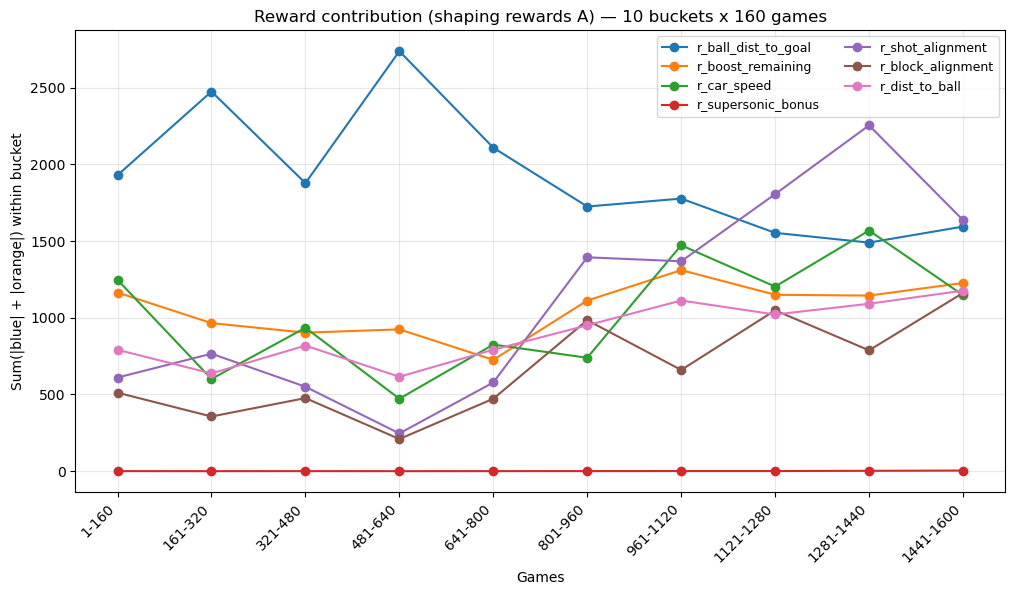

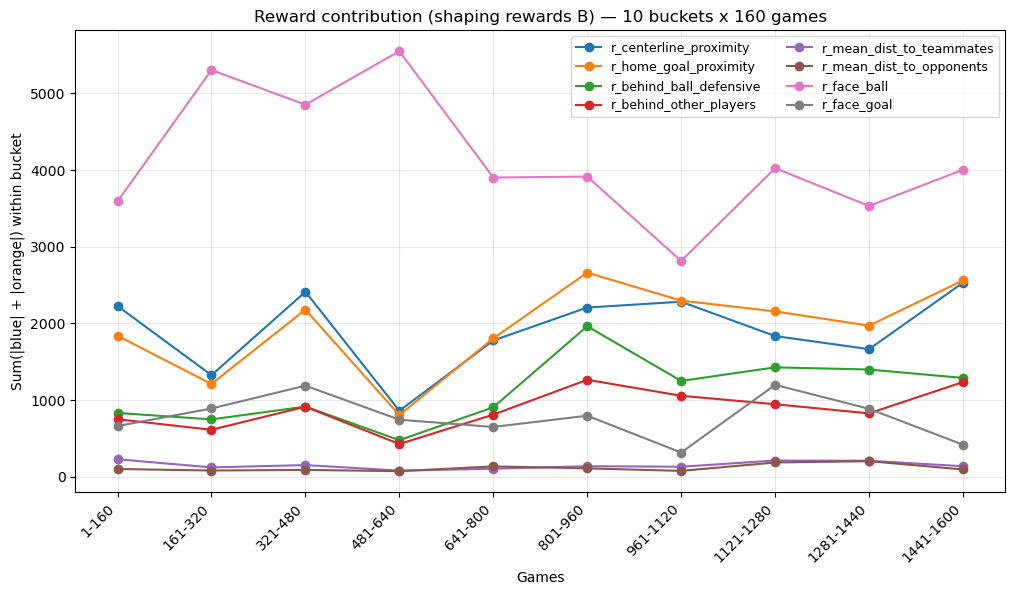

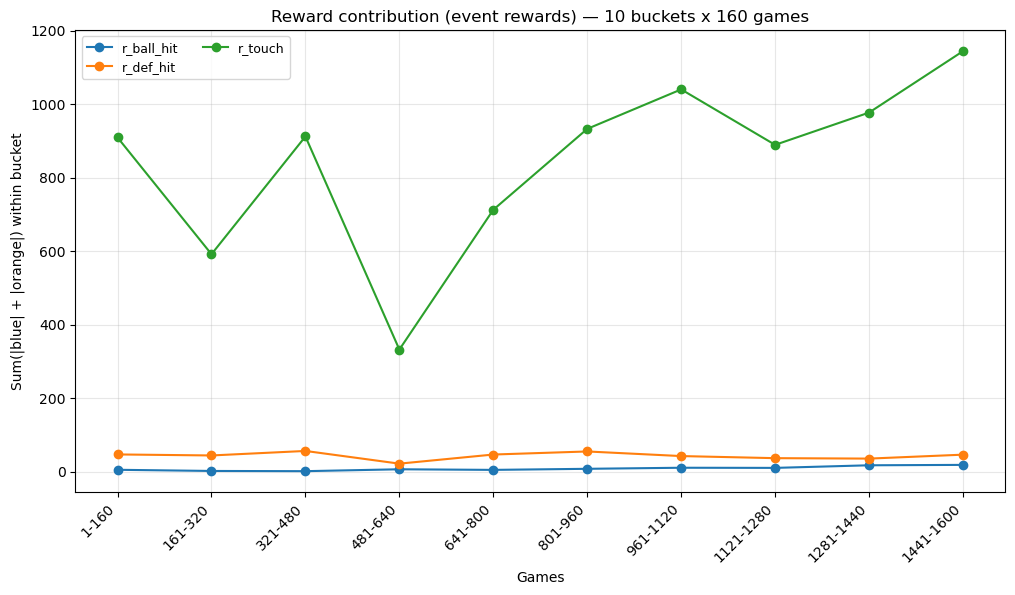

In [24]:
def plot_bucket_lines(bucket_df: pd.DataFrame, bucket_col: str, title: str):
    x = bucket_df[bucket_col].values
    plt.figure(figsize=(12, 6))
    for c in bucket_df.columns:
        if c == bucket_col:
            continue
        plt.plot(x, bucket_df[c].values, marker="o", label=c)
    plt.xlabel("Games")
    plt.ylabel("Sum(|blue| + |orange|) within bucket")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(ncols=2, fontsize=9)

    # Pretty x-axis labels as ranges
    if bucket_col == "bucket_10":
        step = 160
        labels = [f"{int(b)*step+1}-{(int(b)+1)*step}" for b in x]
        plt.xticks(x, labels, rotation=45, ha="right")
    plt.show()

plot_bucket_lines(bucket_small_a, "bucket_10", "Reward contribution (shaping rewards A) — 10 buckets x 160 games")
plot_bucket_lines(bucket_small_b, "bucket_10", "Reward contribution (shaping rewards B) — 10 buckets x 160 games")

plot_bucket_lines(bucket_event, "bucket_10", "Reward contribution (event rewards) — 10 buckets x 160 games")


## 2) Team-level reward dynamics (team-local 8×matchup buckets)

Matchups are scheduled in random order. Each matchup is a **batch of 5 games**.

For *each team independently*, we:
1. Walk through that team’s appearances in chronological order (by `match_id`).
2. Convert `match_id` → `matchup_block = (match_id-1)//5`.
3. Assign a **team-local matchup sequence** (1,2,3,…) by factorizing the encountered `matchup_block`s.
4. Bucket into blocks of **8 matchups at a time**:

- `bucket_round_half = (matchup_seq-1)//8`  (team-local; despite the legacy name)

Self-play (`blue_team == orange_team`) is counted **twice** (as both blue and orange games).

For each reward we compute **positive** and **negative** sums separately for that team:
- `pos_sum += max(0, r_team)`
- `neg_sum += min(0, r_team)`


In [30]:
GAMES_PER_MATCHUP = 5
MATCHUPS_PER_BUCKET = 8

def compute_team_bucket_map(df: pd.DataFrame,
                            team_col_blue: str = "blue_team",
                            team_col_orange: str = "orange_team",
                            match_id_col: str = "match_id",
                            games_per_matchup: int = GAMES_PER_MATCHUP,
                            matchups_per_bucket: int = MATCHUPS_PER_BUCKET) -> dict[str, pd.Series]:
    """
    Returns {team: Series(bucket, index=df_index)} for rows where the team appears.
    Buckets are team-local: contiguous in each team's own appearance order.
    """
    teams_local = sorted(set(df[team_col_blue]).union(set(df[team_col_orange])))
    out = {}
    matchup_block = ((df[match_id_col] - 1) // games_per_matchup).astype(int)

    for t in teams_local:
        mask = (df[team_col_blue] == t) | (df[team_col_orange] == t)
        idx = df.index[mask]
        mb = matchup_block.loc[idx]

        # Factorize in appearance order (sort=False) to get 1..K contiguous matchups for this team
        matchup_seq = pd.factorize(mb, sort=False)[0] + 1
        bucket = ((matchup_seq - 1) // matchups_per_bucket).astype(int)

        out[t] = pd.Series(bucket, index=idx, name="bucket_round_half")
    return out

# Build team-local bucket maps (reward_df)
team_bucket_map = compute_team_bucket_map(reward_df)

# Pre-parse reward pairs into numeric arrays to keep later loops fast.
parsed_rewards = {}
for r in reward_cols_small + reward_cols_event:
    parsed_rewards[r] = parse_pair_series(reward_df[r]).values  # shape (N,2) => [blue, orange]


In [31]:
teams = sorted(set(reward_df["blue_team"]).union(set(reward_df["orange_team"])))

def team_side_values_for_match(team: str, blue_team: str, orange_team: str, pair_vals: np.ndarray) -> list[float]:
    """Return list of reward values for `team` in this match (length 0,1, or 2 for self-play)."""
    out = []
    if team == blue_team:
        out.append(float(pair_vals[0]))
    if team == orange_team:
        out.append(float(pair_vals[1]))
    return out

def aggregate_team_rewards(team: str, bucket_col: str, reward_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return (pos_df, neg_df, cnt_df) by team-local bucket. Self-play counts twice."""
    tb = team_bucket_map.get(team)
    if tb is None or len(tb) == 0:
        return (pd.DataFrame(columns=[bucket_col] + reward_cols),
                pd.DataFrame(columns=[bucket_col] + reward_cols),
                pd.DataFrame(columns=[bucket_col, "team_games"]))

    buckets = sorted(tb.unique())
    pos = pd.DataFrame(0.0, index=buckets, columns=reward_cols)
    neg = pd.DataFrame(0.0, index=buckets, columns=reward_cols)
    counts = pd.Series(0, index=buckets, dtype=int)  # number of 'team games' (self-play counts twice)

    for i, row in reward_df.iterrows():
        if i not in tb.index:
            continue
        b = int(tb.loc[i])
        blue_t = row["blue_team"]
        orange_t = row["orange_team"]

        appeared = 0
        if team == blue_t: appeared += 1
        if team == orange_t: appeared += 1
        if appeared == 0:
            continue

        counts[b] += appeared

        for r in reward_cols:
            pair = parsed_rewards[r][i]  # [blue, orange]
            vals = team_side_values_for_match(team, blue_t, orange_t, pair)
            for v in vals:
                if v >= 0:
                    pos.loc[b, r] += v
                else:
                    neg.loc[b, r] += v

    pos_df = pos.reset_index().rename(columns={"index": bucket_col})
    neg_df = neg.reset_index().rename(columns={"index": bucket_col})
    cnt_df = counts.reset_index().rename(columns={"index": bucket_col, 0: "team_games"})
    return pos_df, neg_df, cnt_df

# Example: pick first team to sanity check
example_team = teams[0]
pos_ex, neg_ex, cnt_ex = aggregate_team_rewards(example_team, "bucket_round_half", reward_cols_small)
display(example_team)
display(cnt_ex.head())
display(pos_ex.head())
display(neg_ex.head())


'team1_striker_balance'

,bucket_round_half,team_games
0,0,45
1,1,45
2,2,40
3,3,40
4,4,40


,bucket_round_half,r_ball_dist_to_goal,r_boost_remaining,r_car_speed,r_supersonic_bonus,r_shot_alignment,r_block_alignment,r_dist_to_ball,r_centerline_proximity,r_home_goal_proximity,r_behind_ball_defensive,r_behind_other_players,r_mean_dist_to_teammates,r_mean_dist_to_opponents,r_face_ball,r_face_goal
0,0,0.0,427.854521,208.252407,0.00000,64.272650,55.026942,0.0,0.0,0.0,14.11000,13.392900,93.715605,0.0,226.724428,1.082210
1,1,0.0,96.038783,2.714552,0.00000,22.073224,6.005663,0.0,0.0,0.0,63.14360,79.520638,0.719384,0.0,579.052106,0.225811
2,2,0.0,84.639507,0.854719,0.00000,4.749830,1.338408,0.0,0.0,0.0,27.69525,51.774723,0.093295,0.0,447.971467,0.000000
3,3,0.0,107.365733,3.870330,0.00000,35.325007,3.301554,0.0,0.0,0.0,69.64435,91.983431,0.007554,0.0,418.768224,0.004332
4,4,0.0,256.368293,32.452351,0.00196,42.719409,90.340653,0.0,0.0,0.0,297.24870,430.208142,0.133592,0.0,246.601070,0.000000


,bucket_round_half,r_ball_dist_to_goal,r_boost_remaining,r_car_speed,r_supersonic_bonus,r_shot_alignment,r_block_alignment,r_dist_to_ball,r_centerline_proximity,r_home_goal_proximity,r_behind_ball_defensive,r_behind_other_players,r_mean_dist_to_teammates,r_mean_dist_to_opponents,r_face_ball,r_face_goal
0,0,-298.729383,0.0,0.0,0.0,-41.557049,-32.348201,-2.376027,-155.109433,-16.989435,-17.41500,0.0,0.0,0.0,-25.438775,-0.291291
1,1,-502.741025,0.0,0.0,0.0,-40.590832,-0.873259,-11.830047,-55.217058,-123.661771,-151.88360,0.0,0.0,0.0,-14.845575,0.000000
2,2,-452.094922,0.0,0.0,0.0,-38.675425,-12.910072,-9.058522,-38.413266,-91.618990,-50.01975,0.0,0.0,0.0,-12.723098,-0.059425
3,3,-413.266834,0.0,0.0,0.0,-17.632258,-11.417608,-20.138752,-79.432374,-175.259477,-41.97295,0.0,0.0,0.0,-19.784713,0.000000
4,4,-145.544288,0.0,0.0,0.0,-9.122417,-74.599287,-126.225691,-413.159304,-818.878978,-427.53480,0.0,0.0,0.0,-228.506560,-0.032449


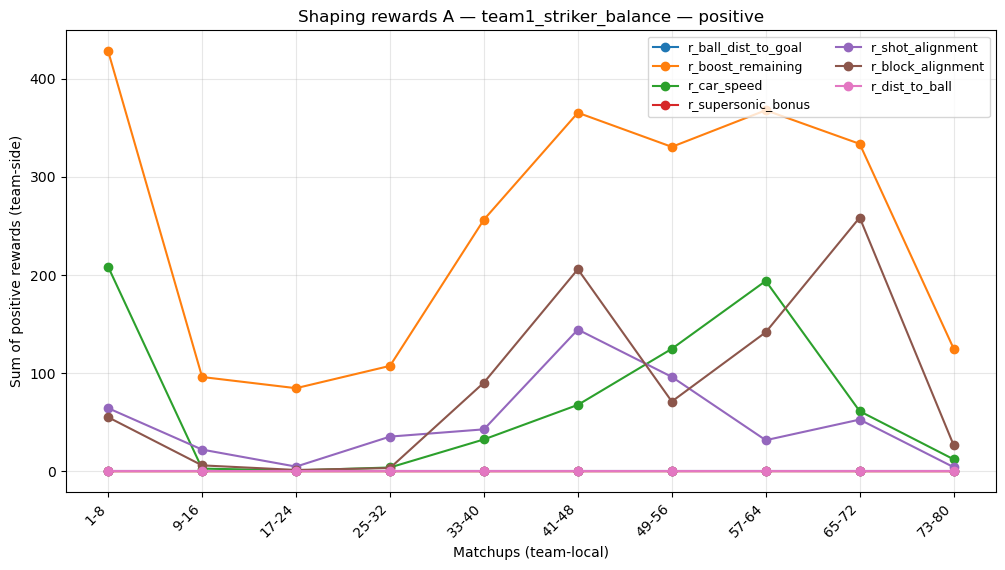

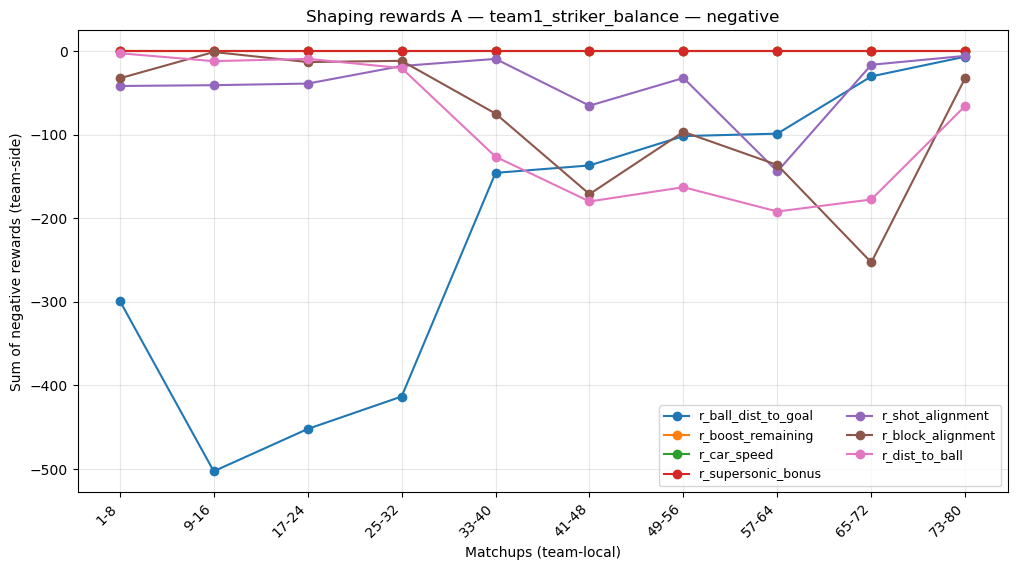

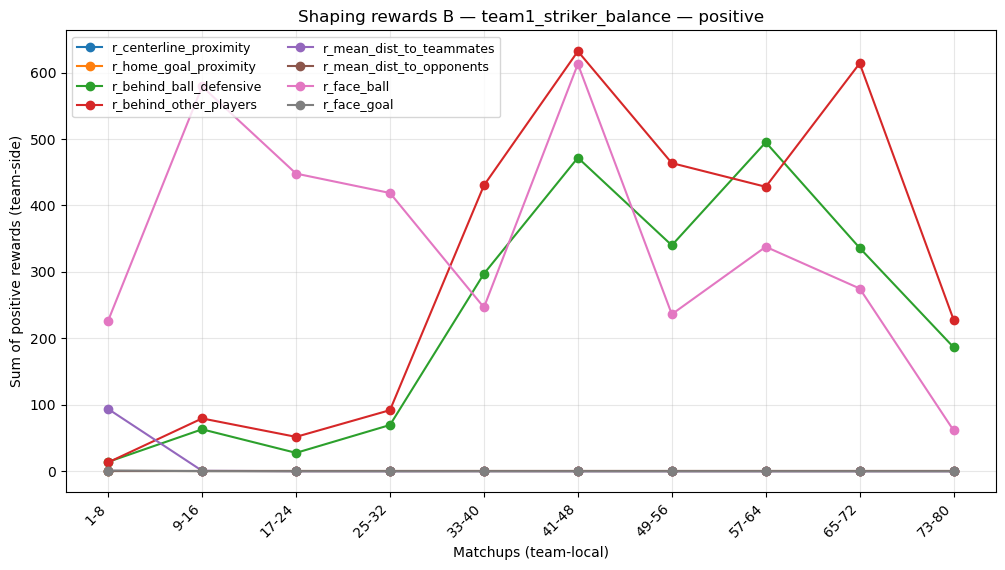

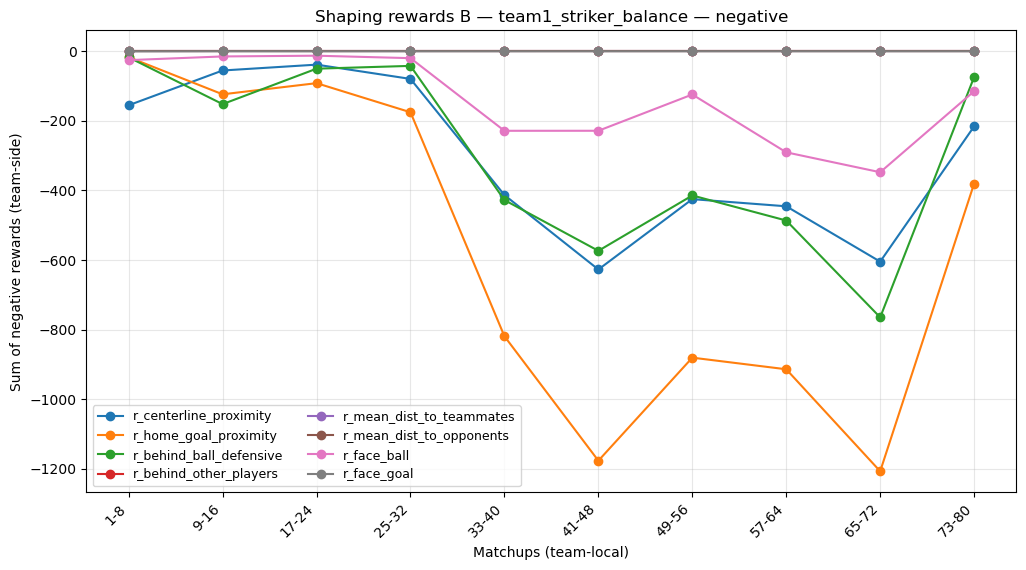

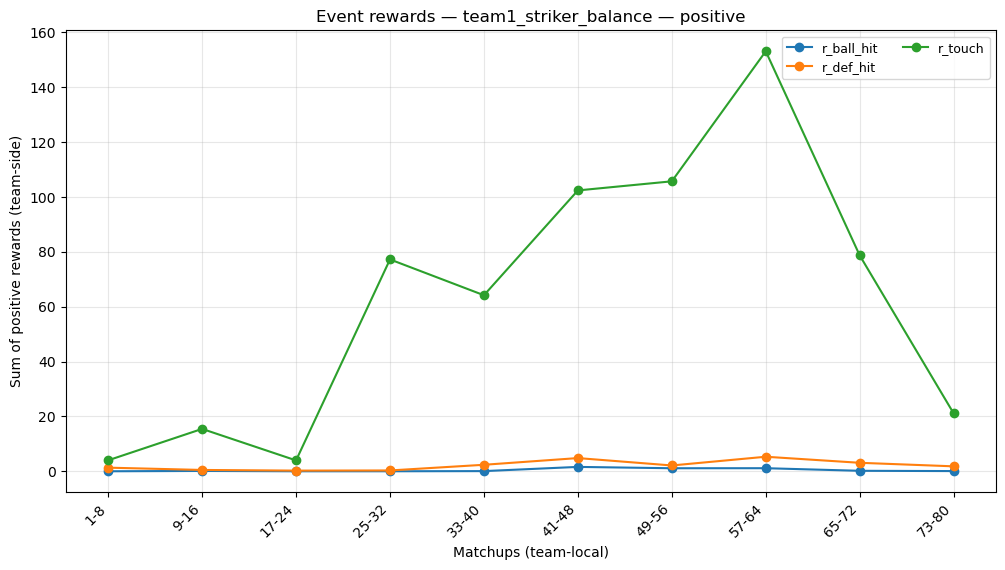

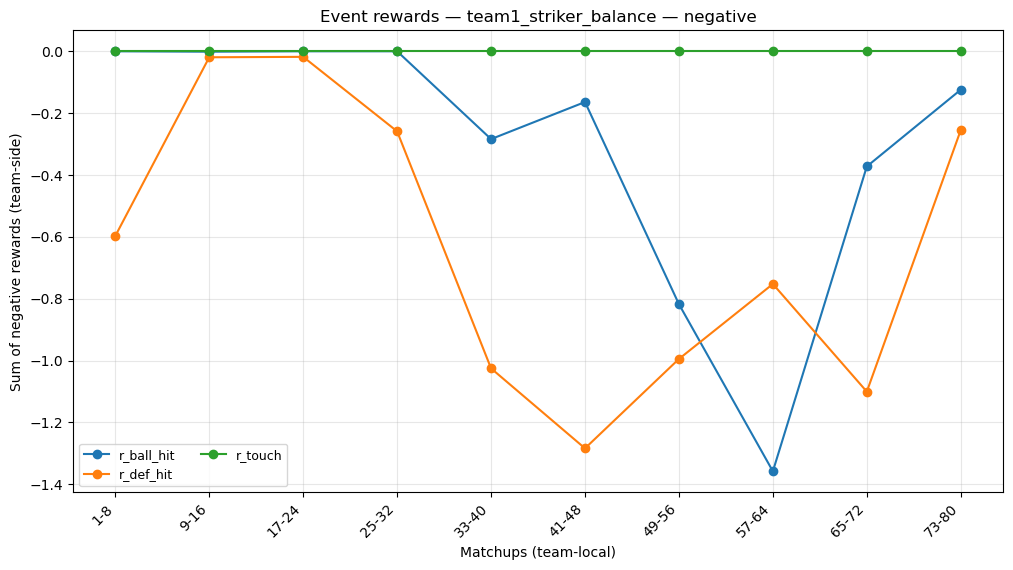

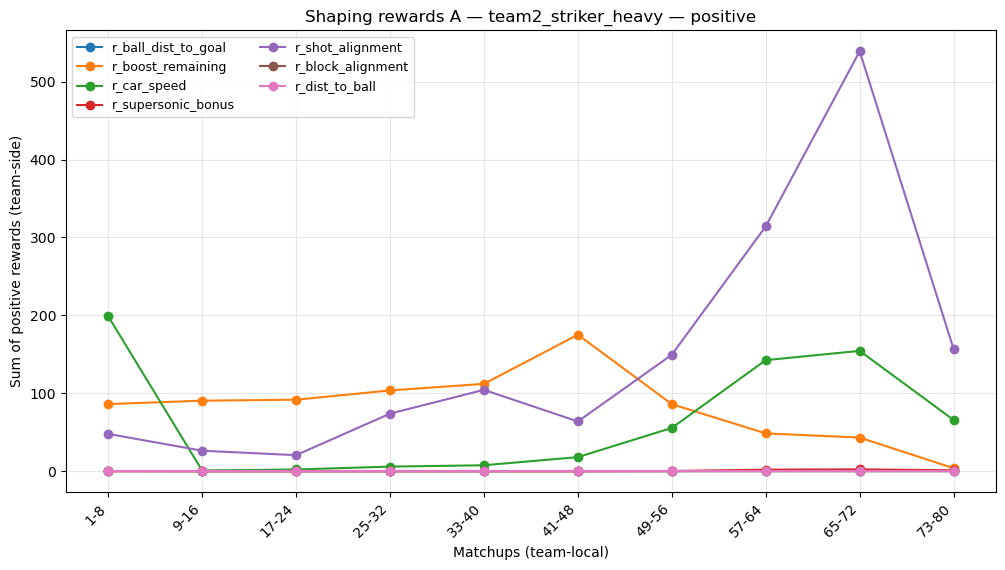

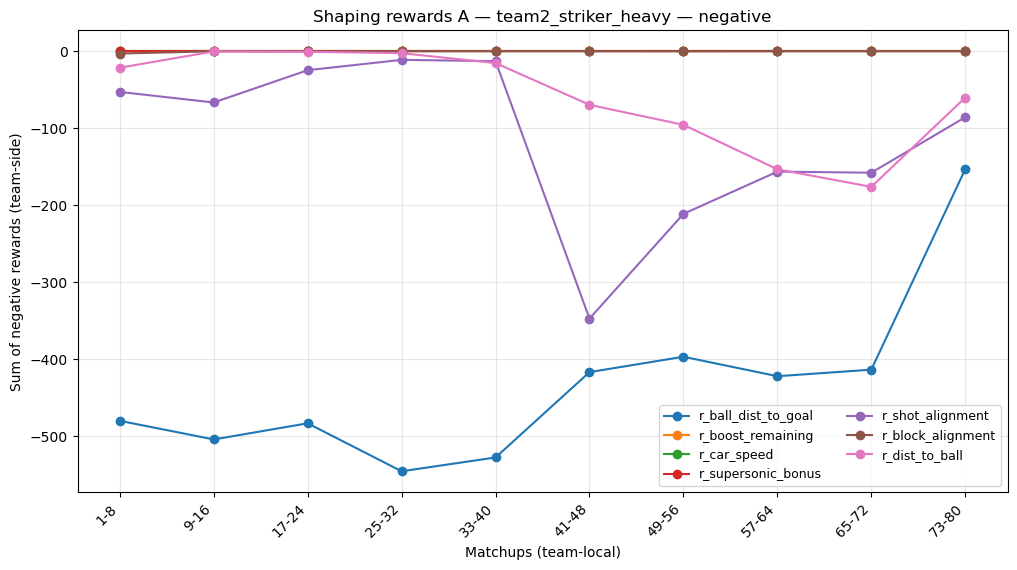

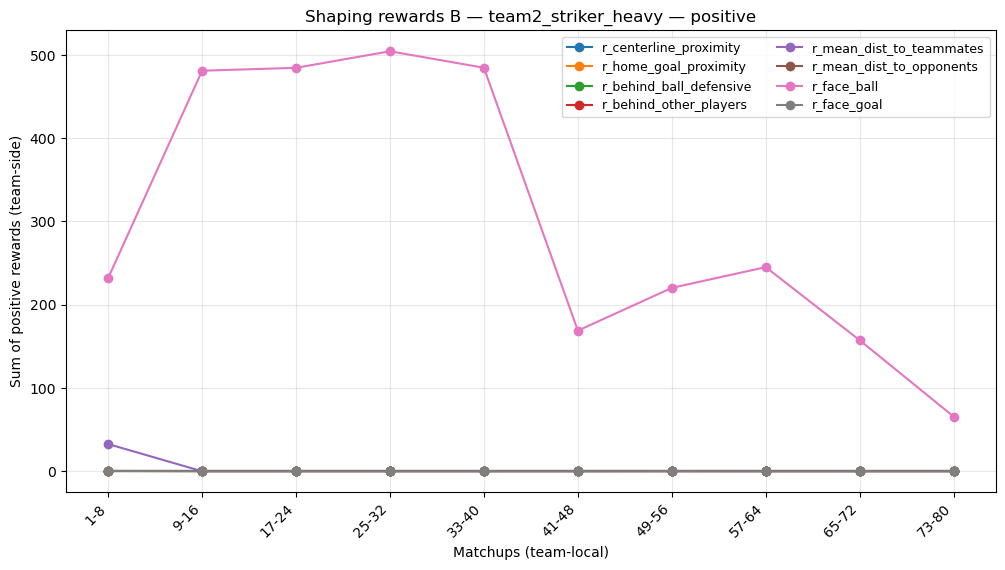

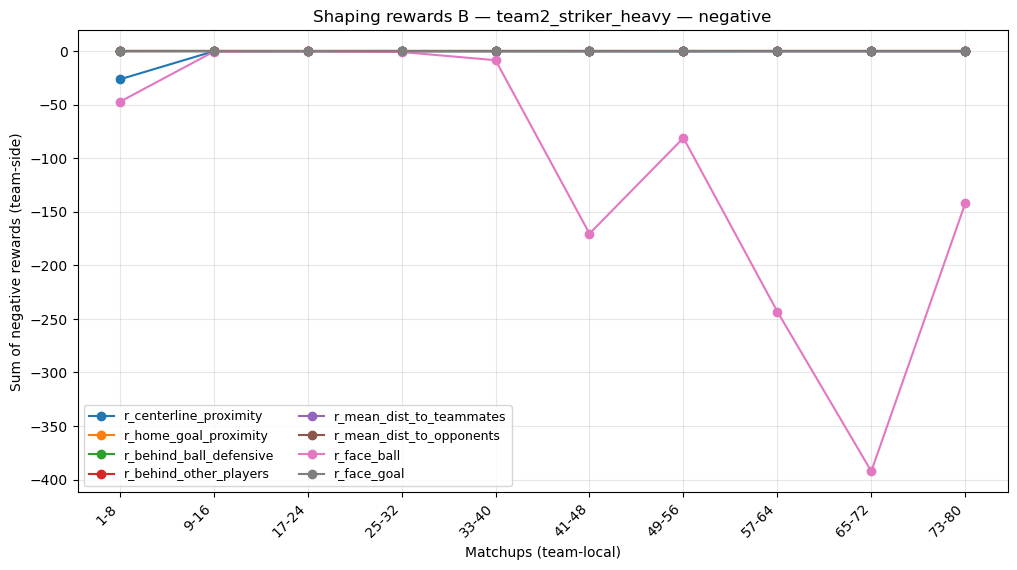

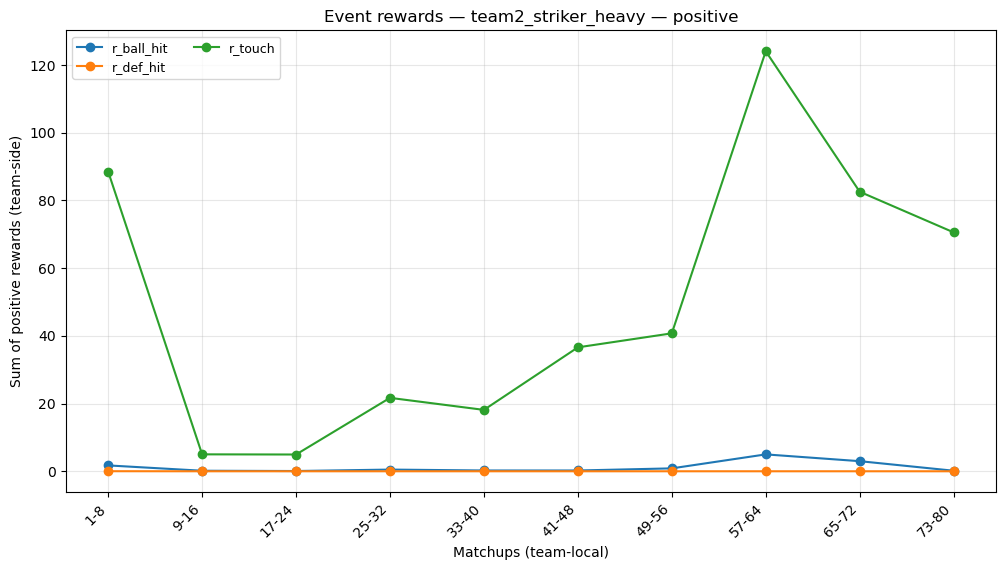

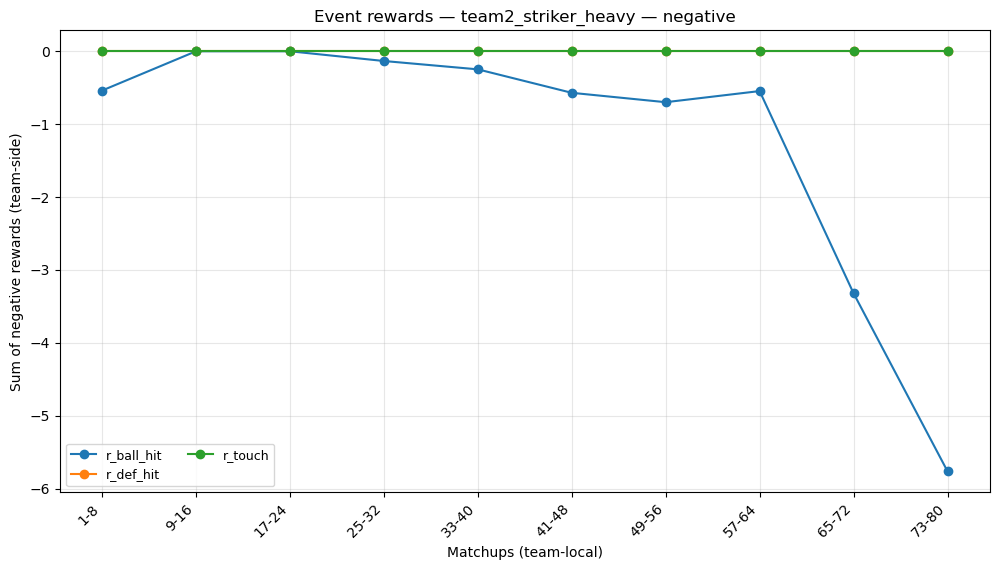

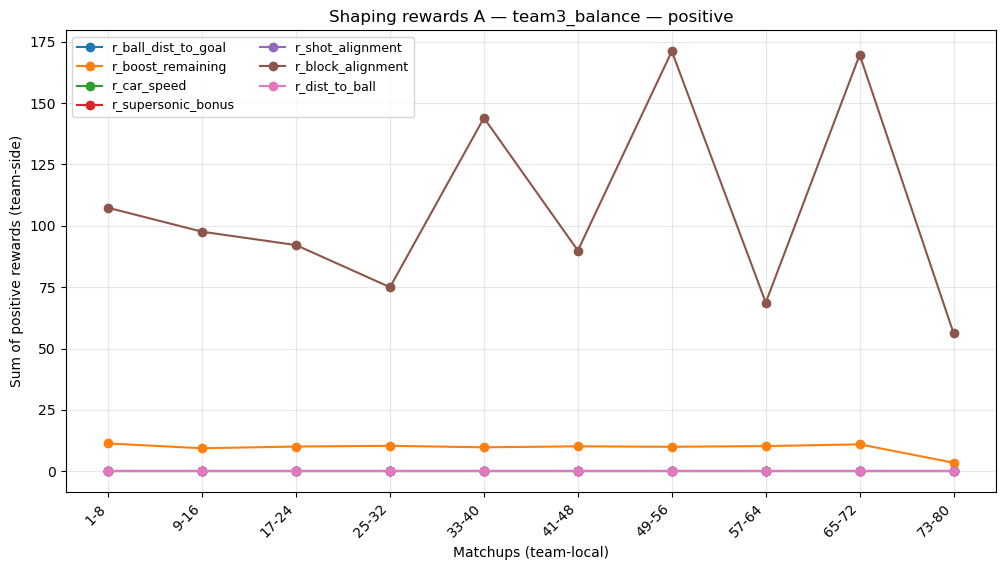

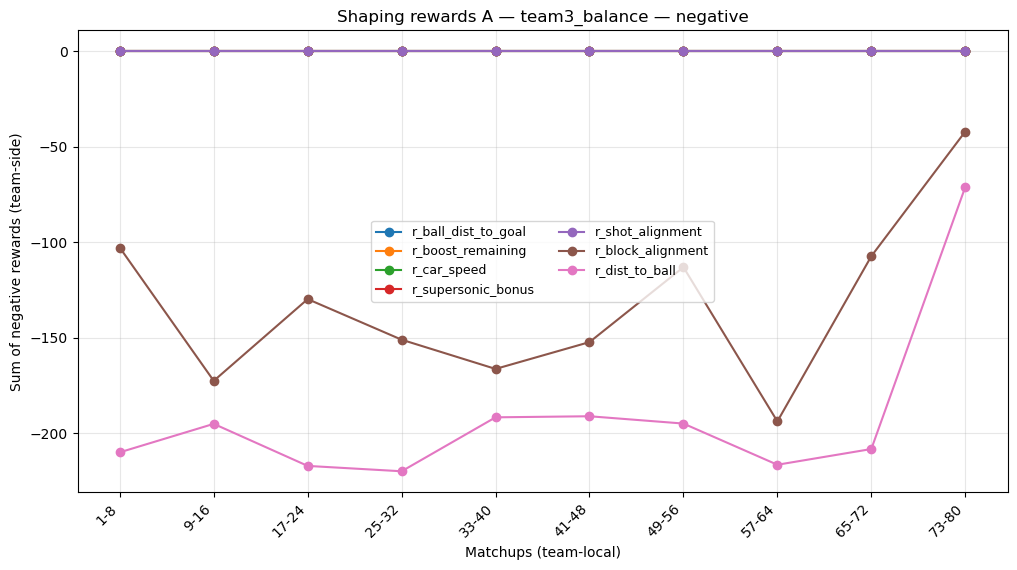

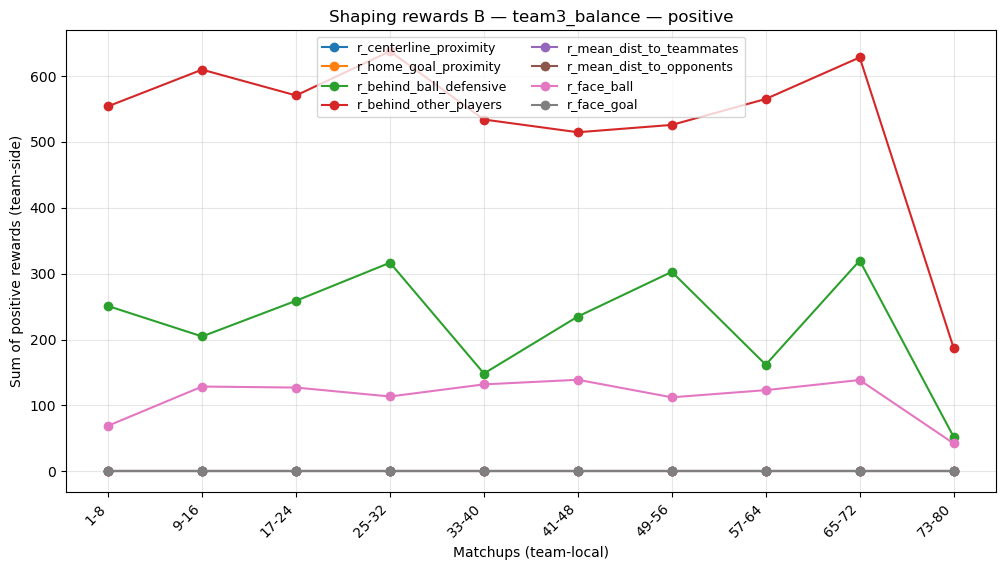

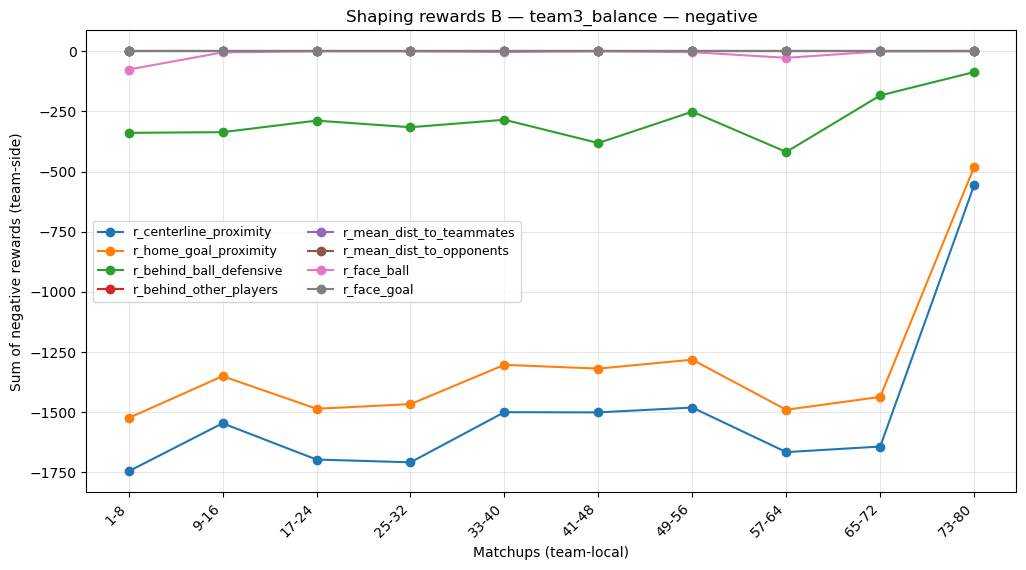

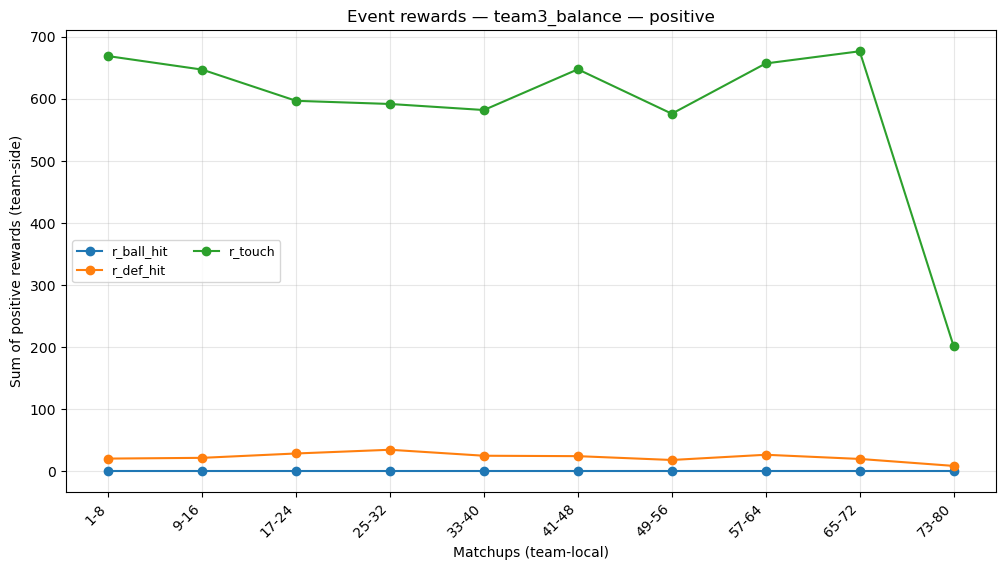

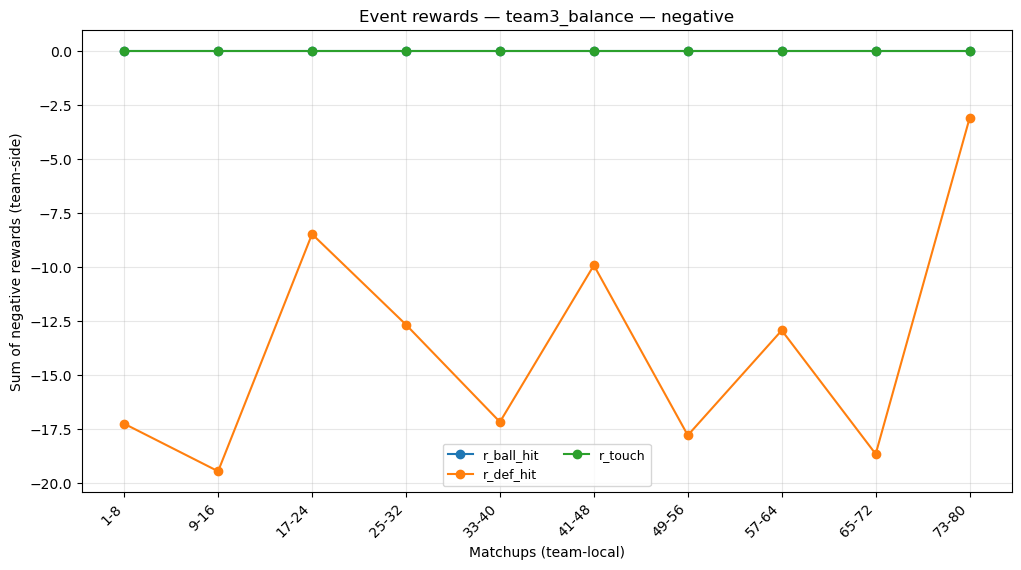

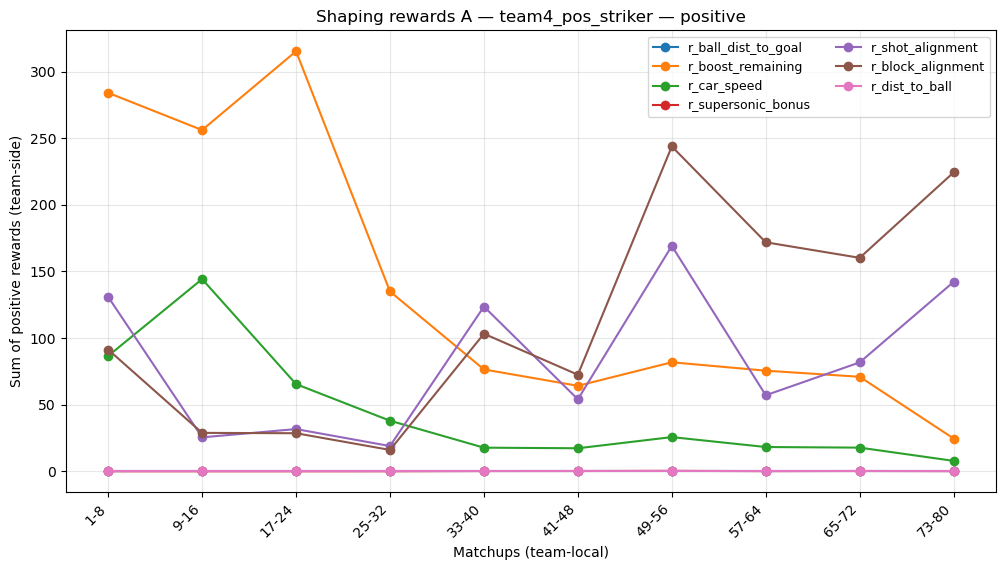

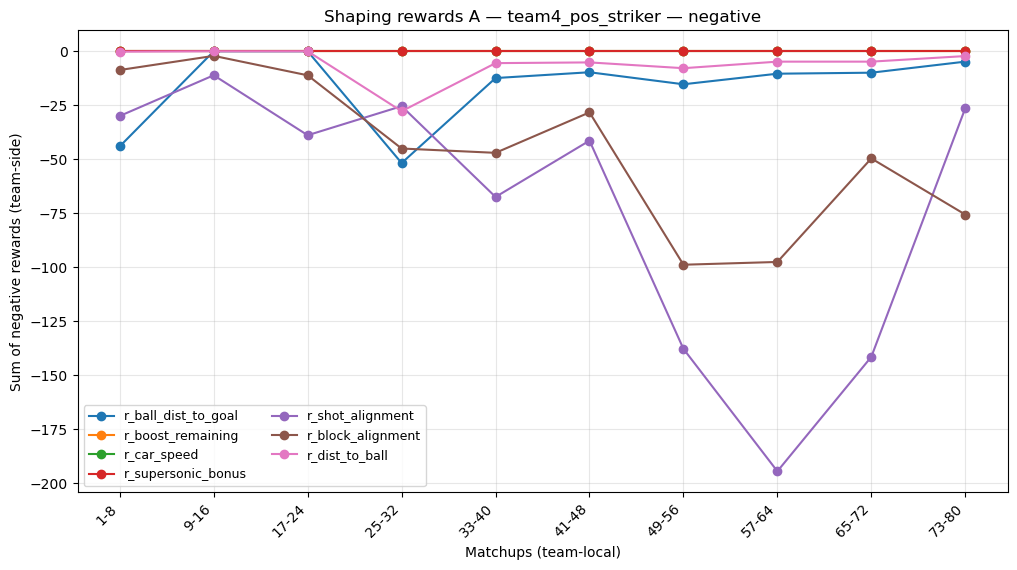

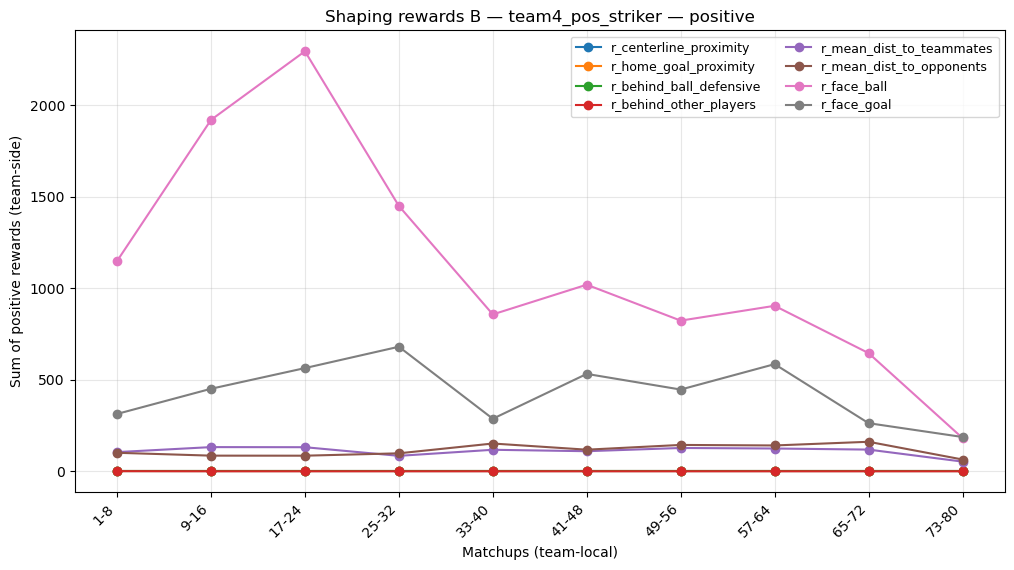

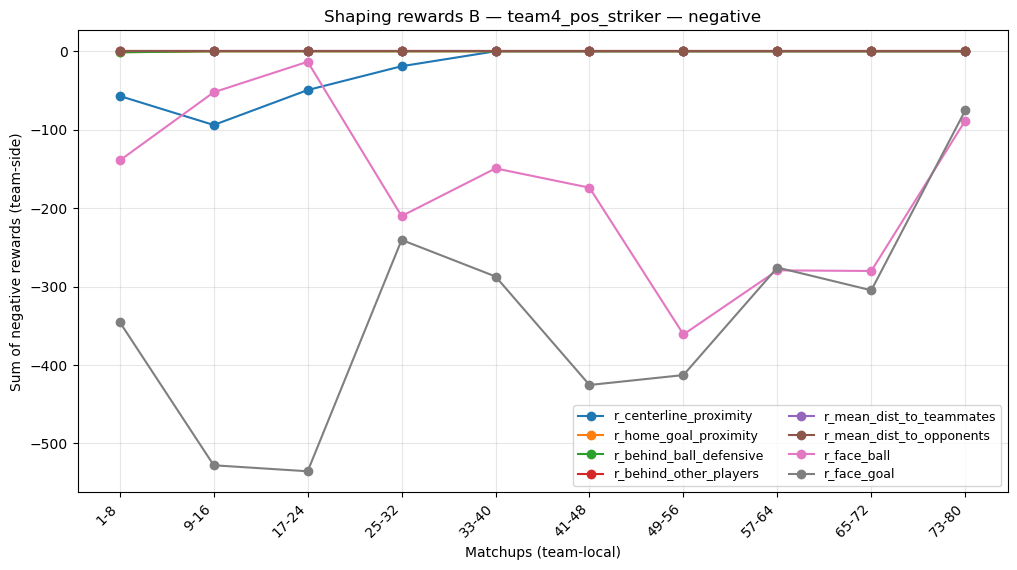

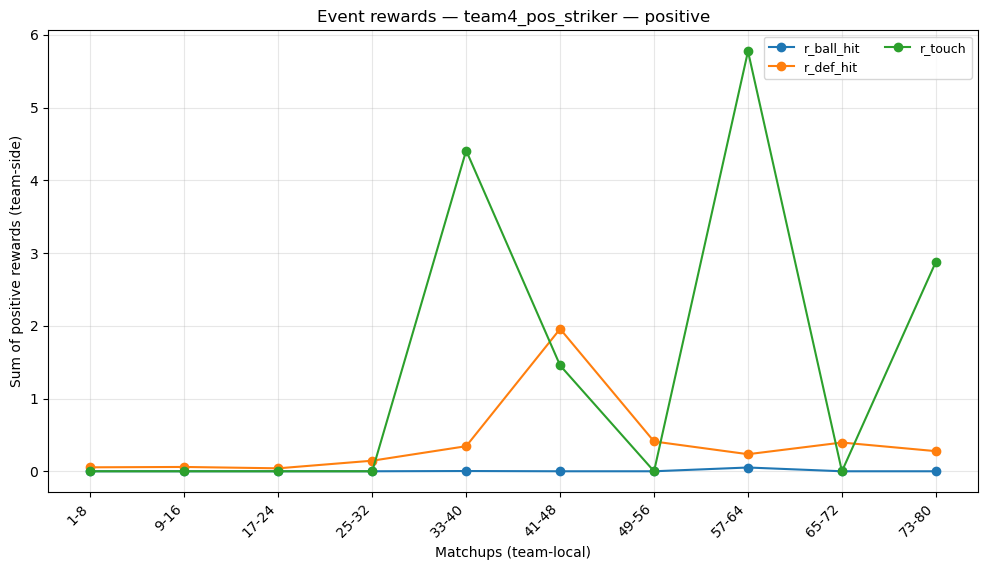

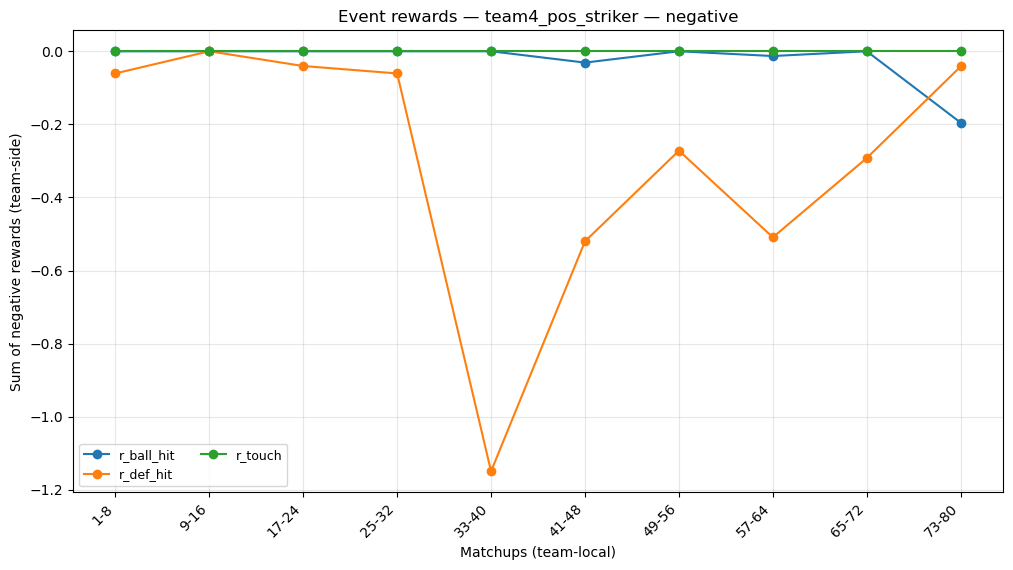

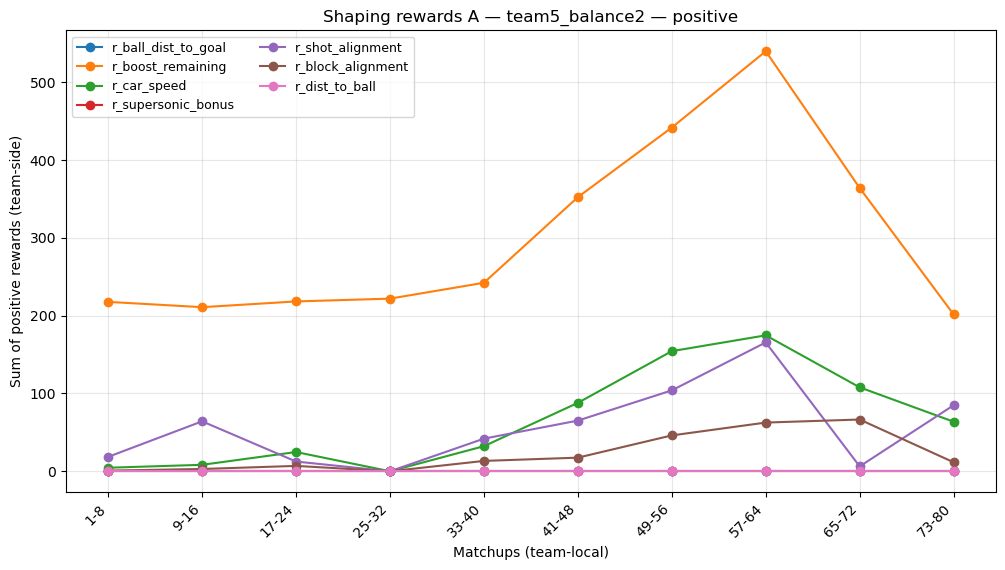

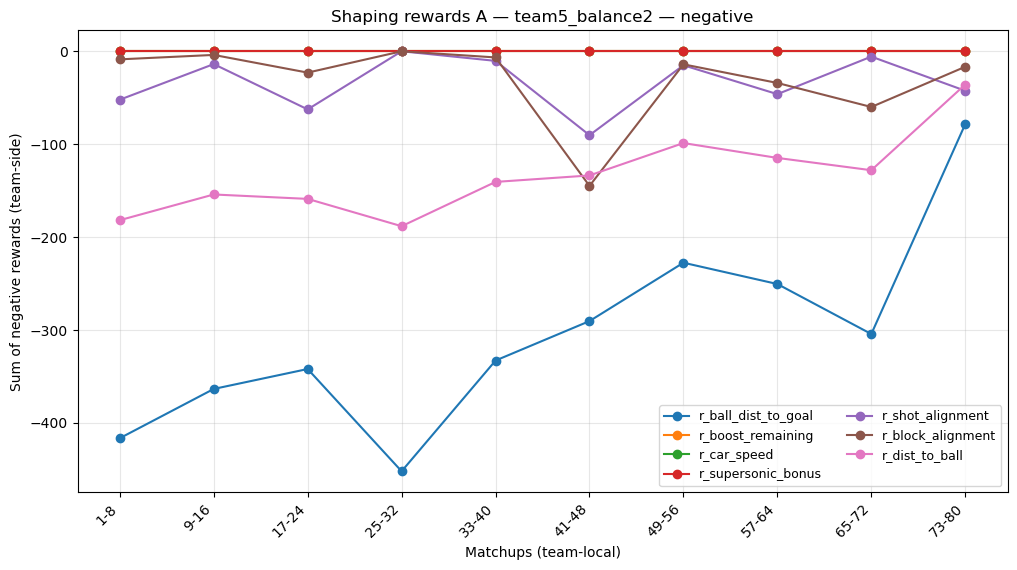

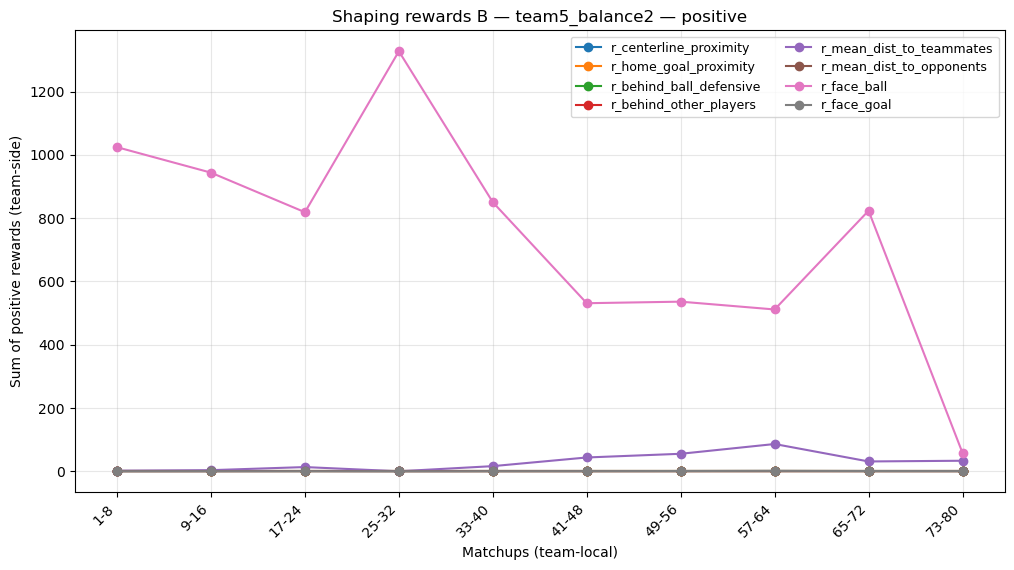

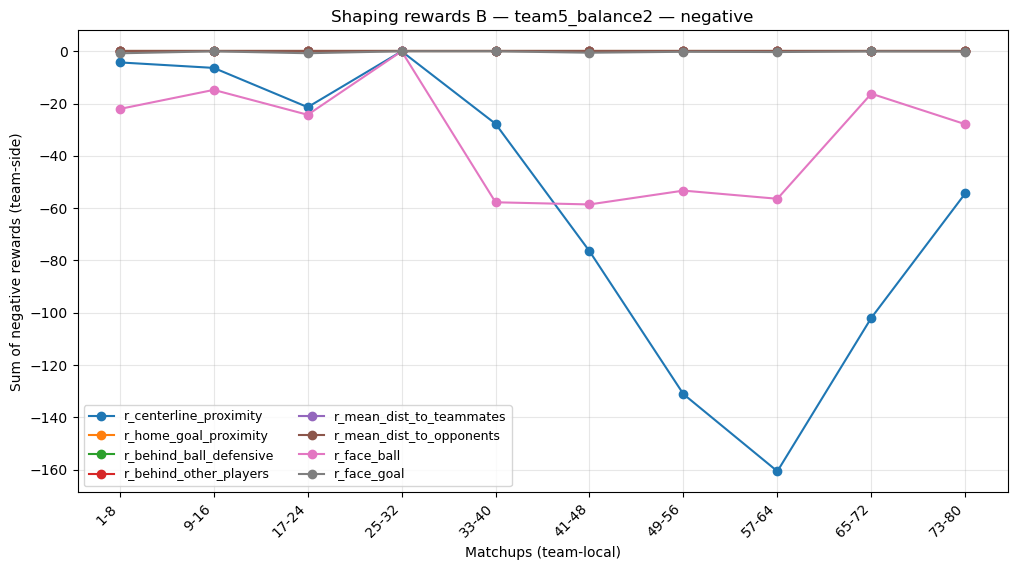

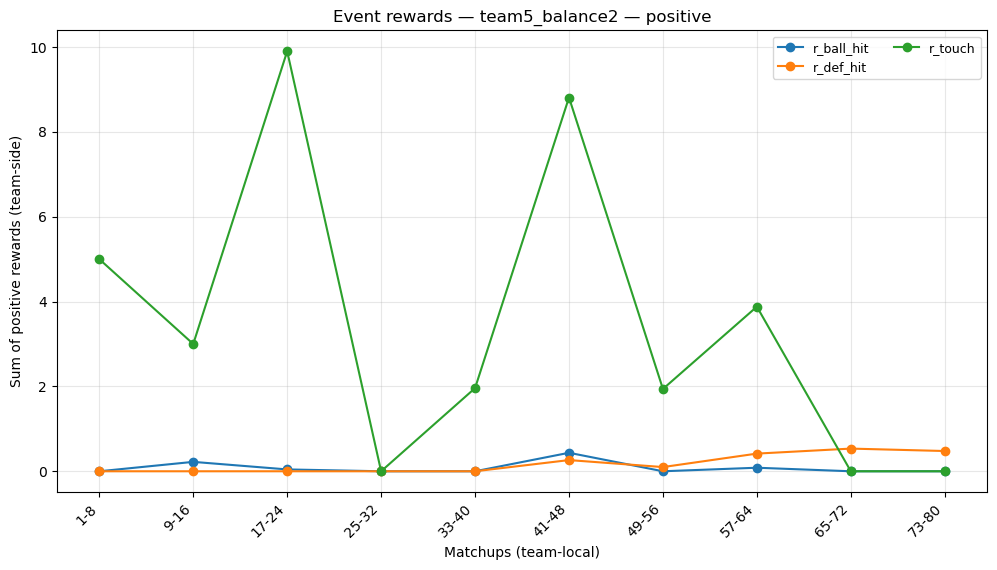

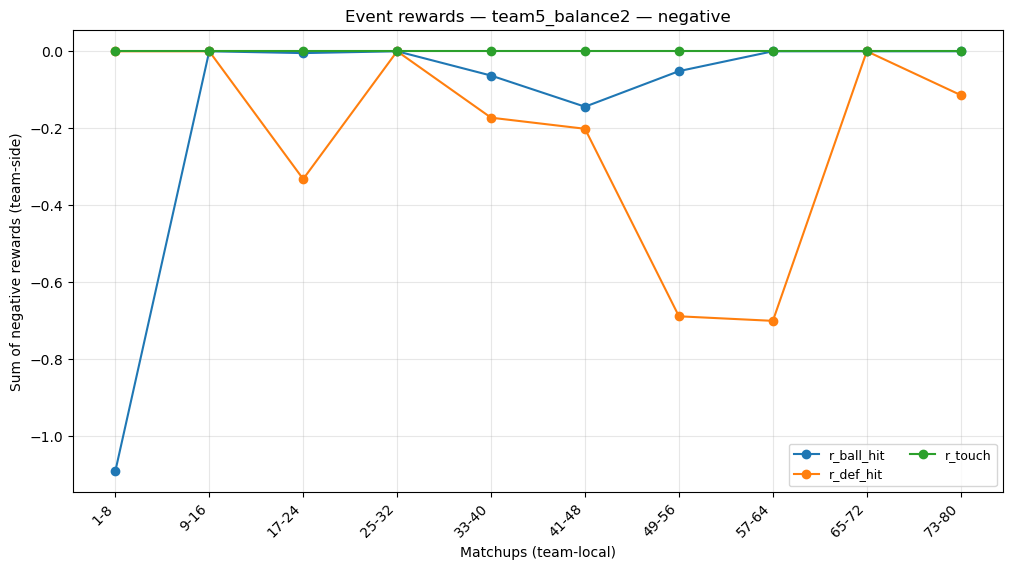

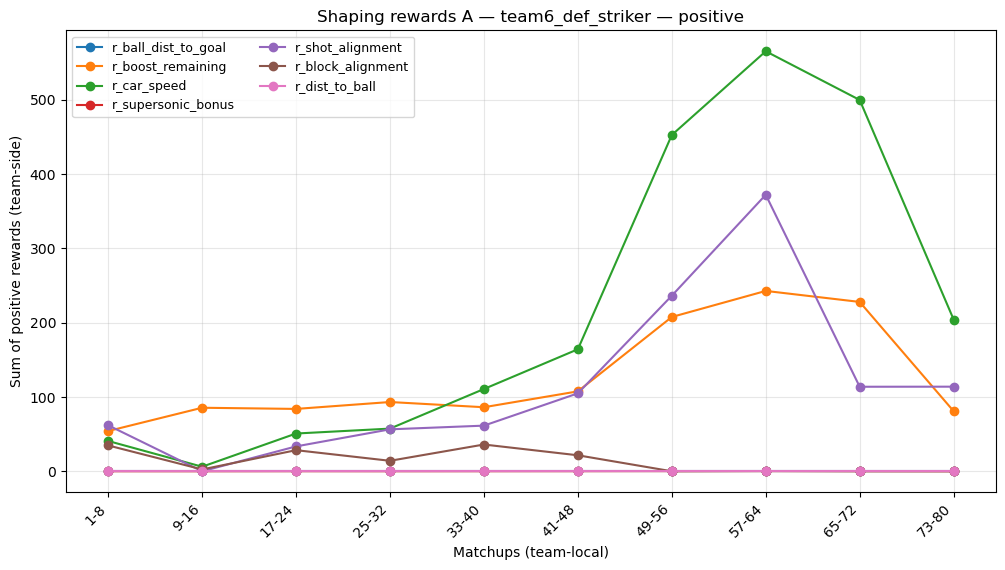

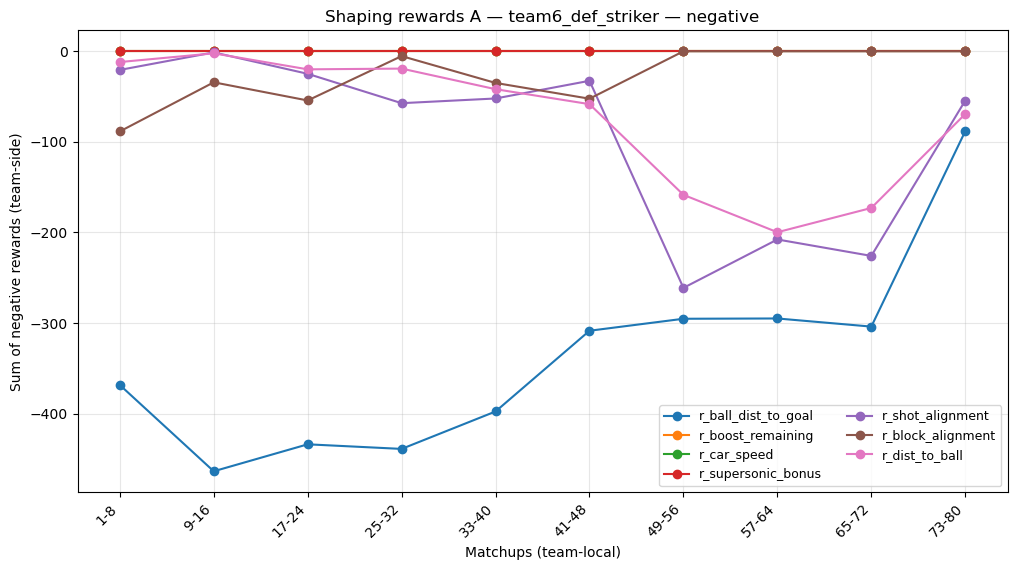

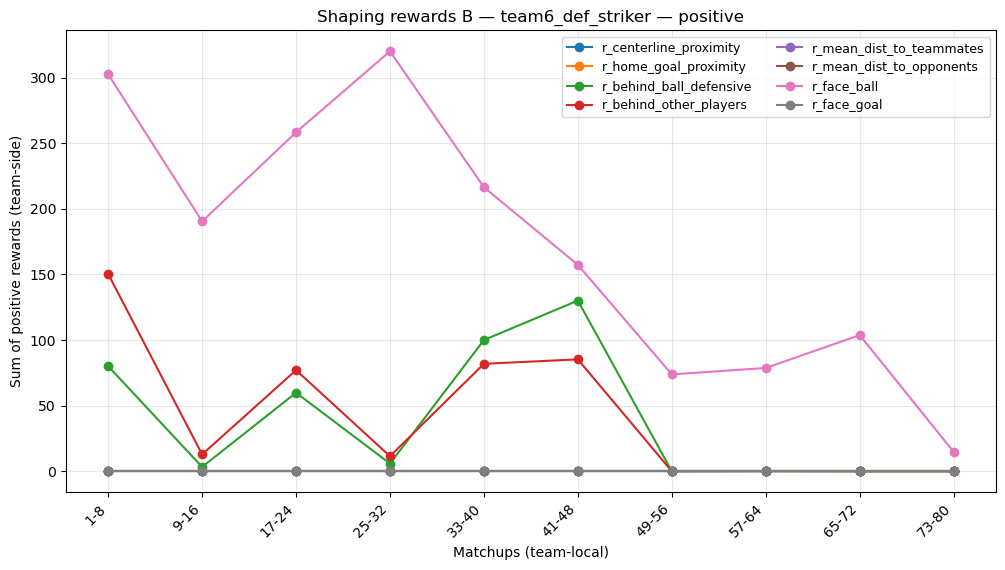

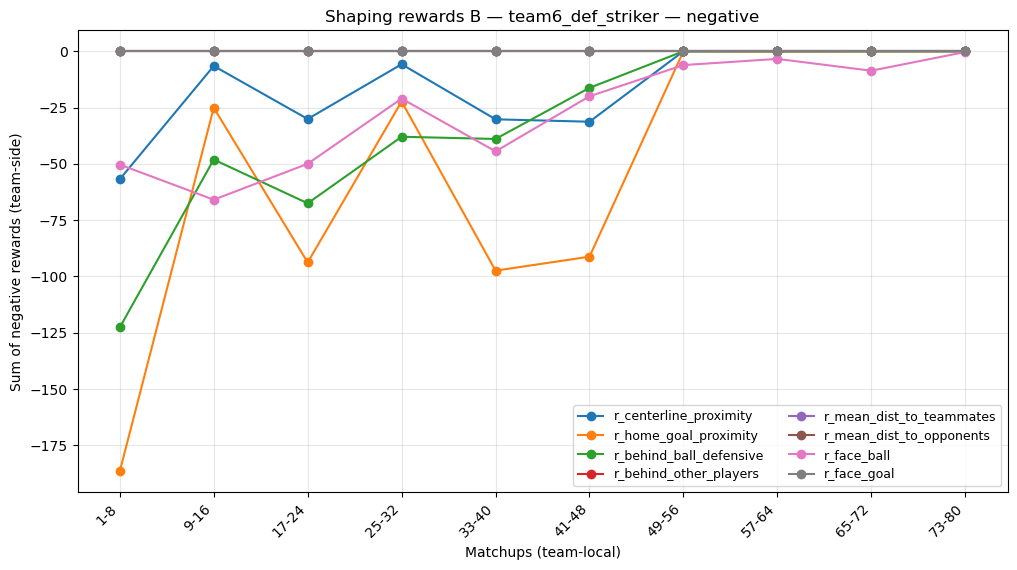

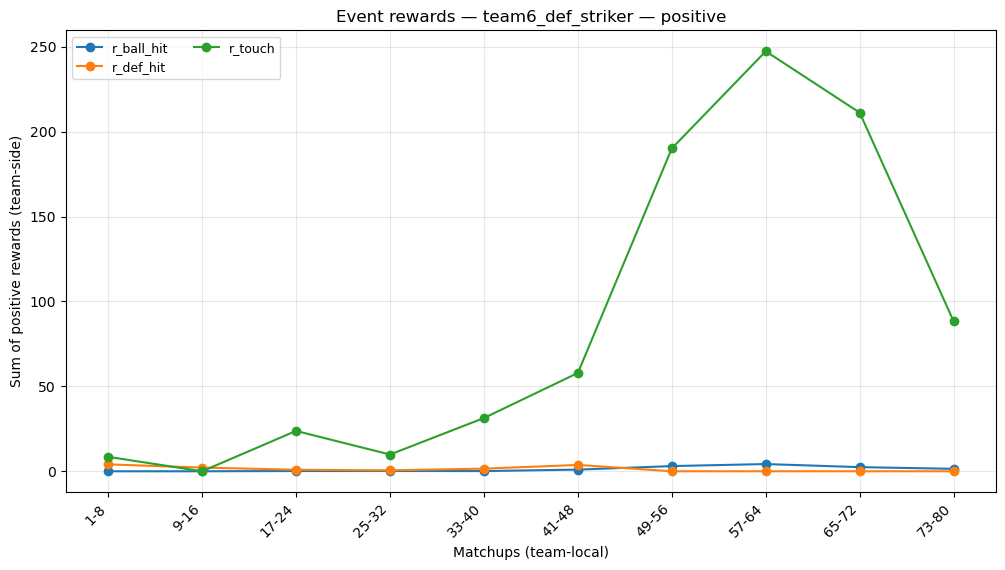

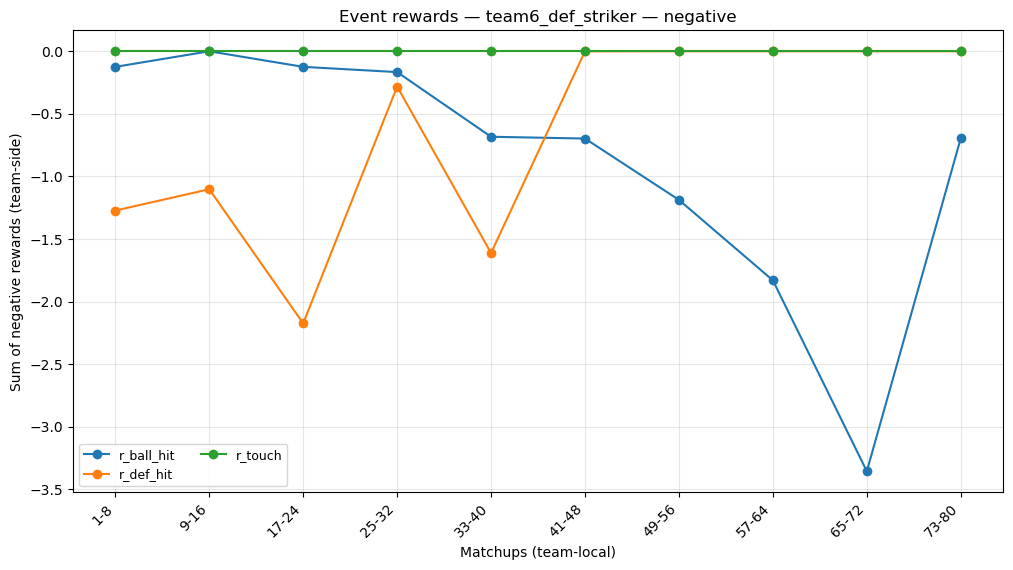

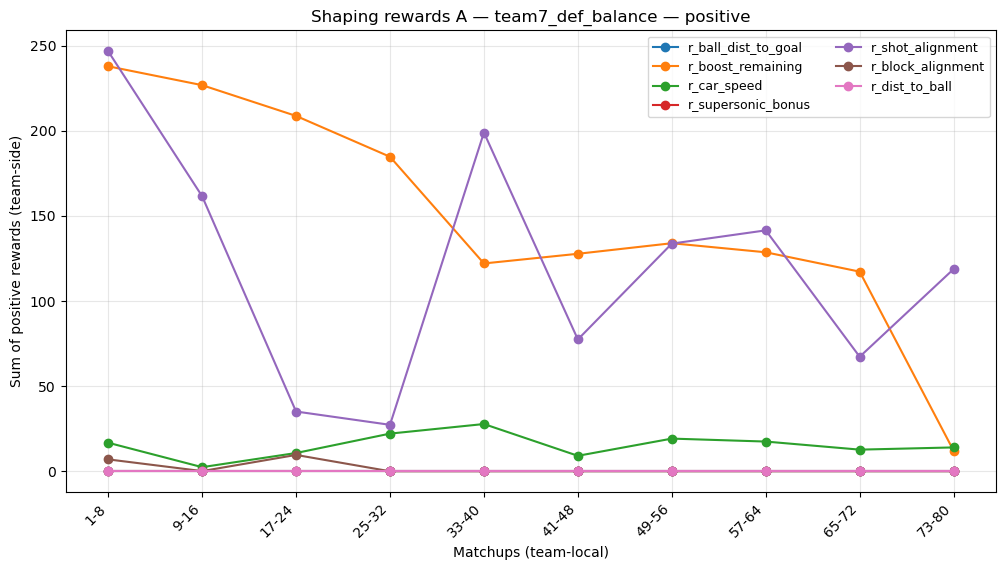

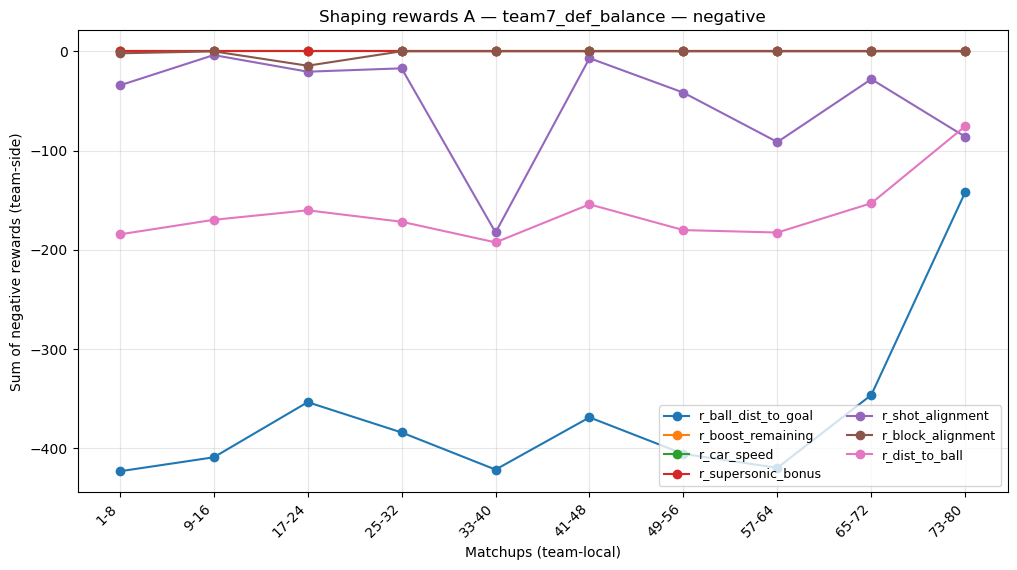

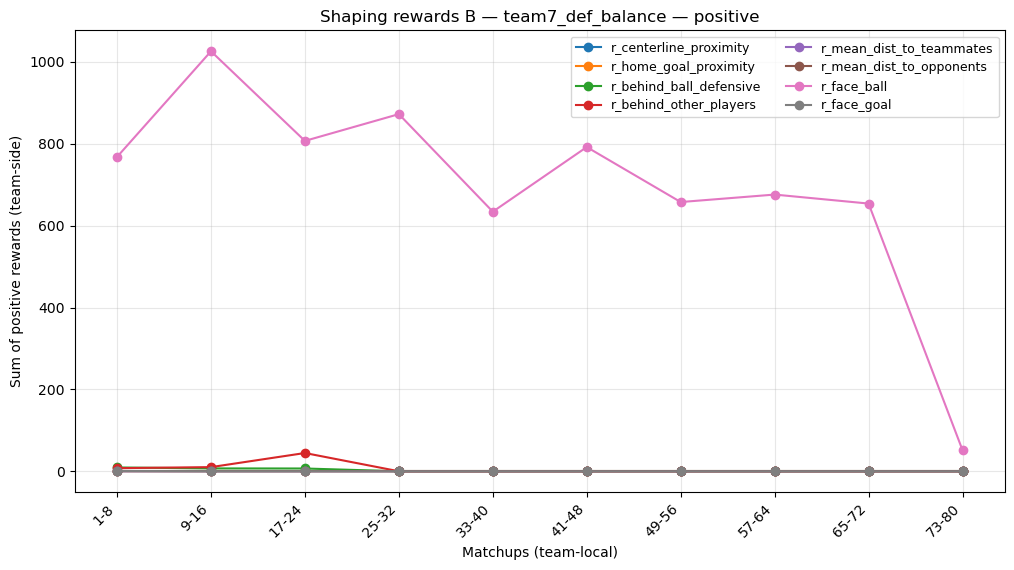

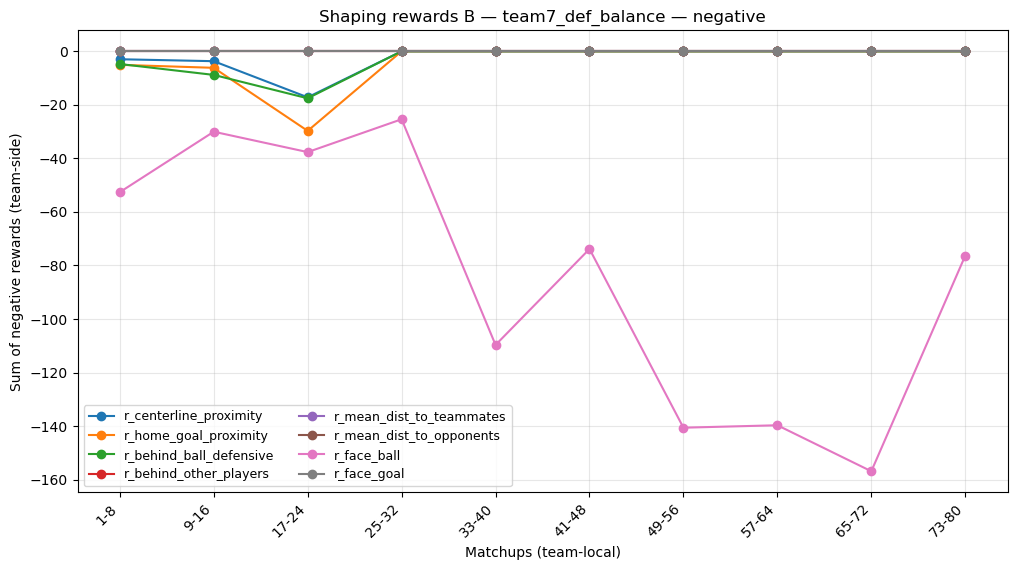

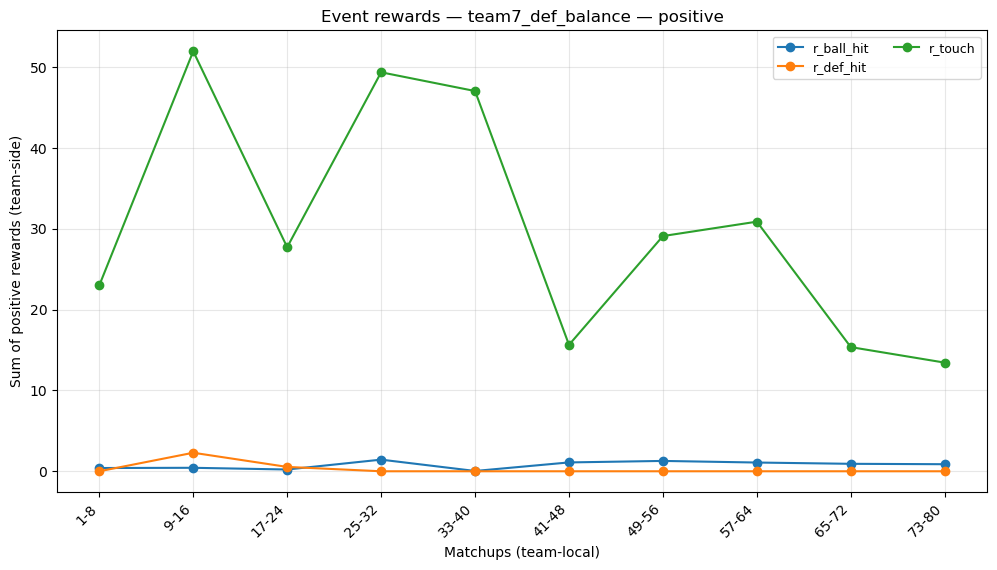

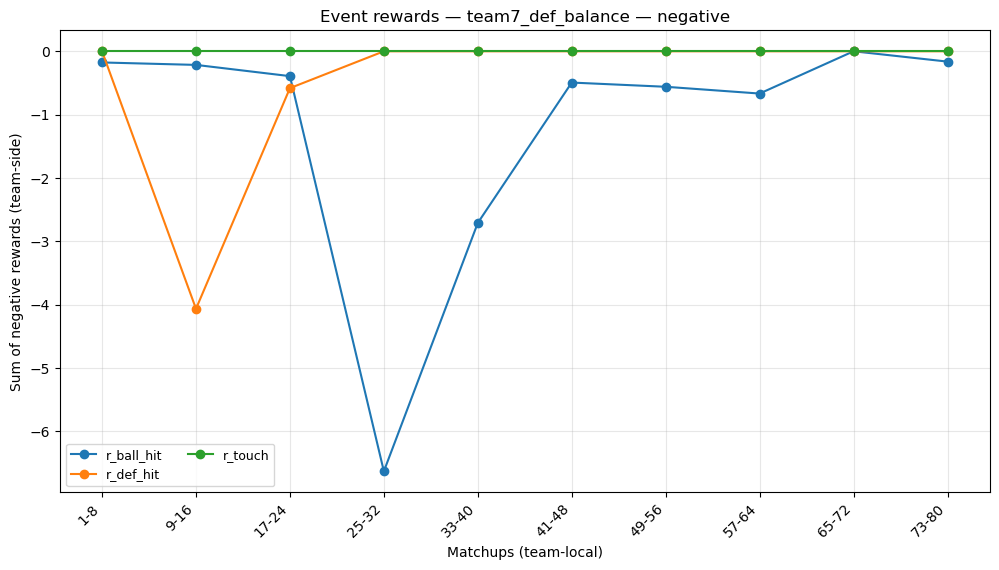

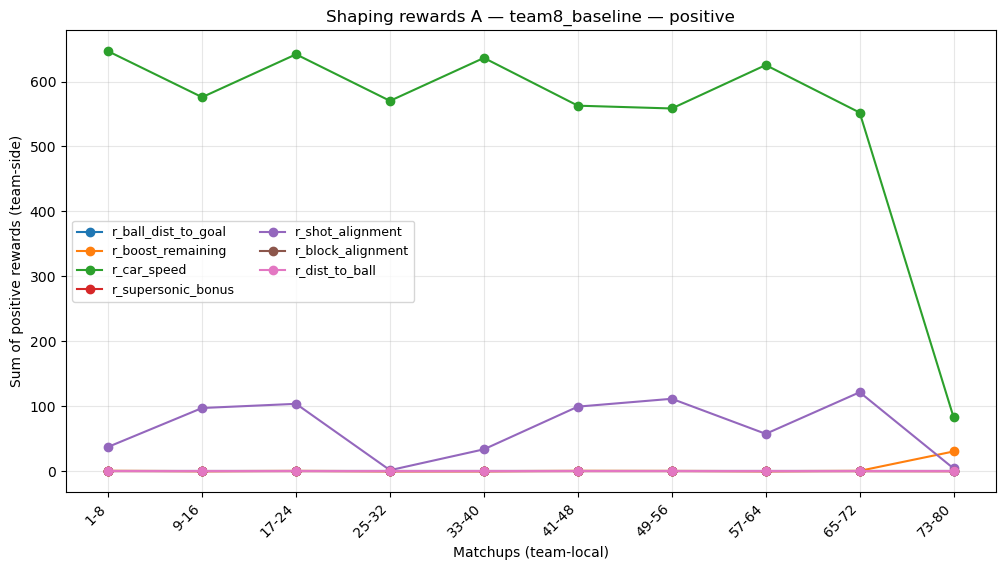

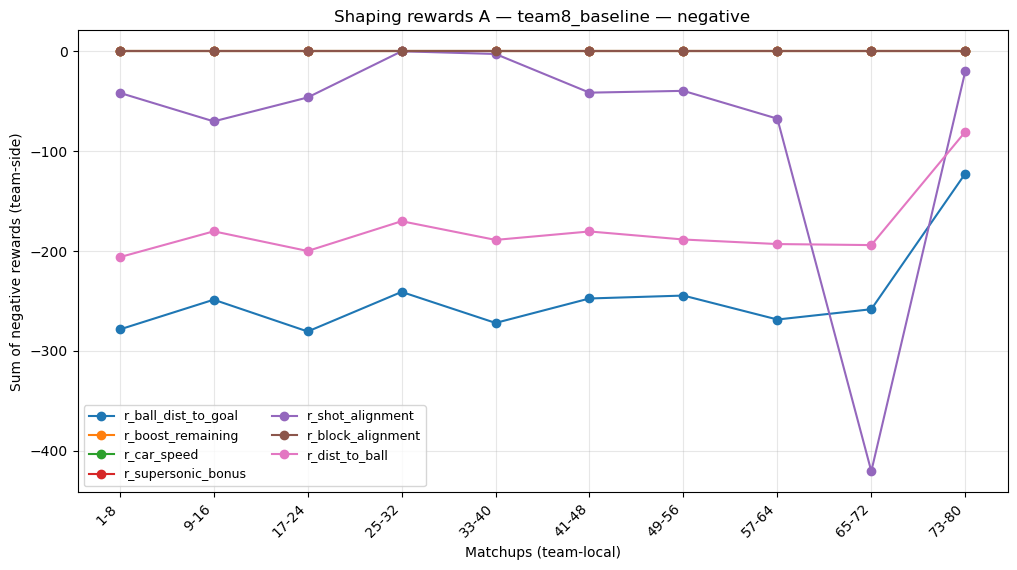

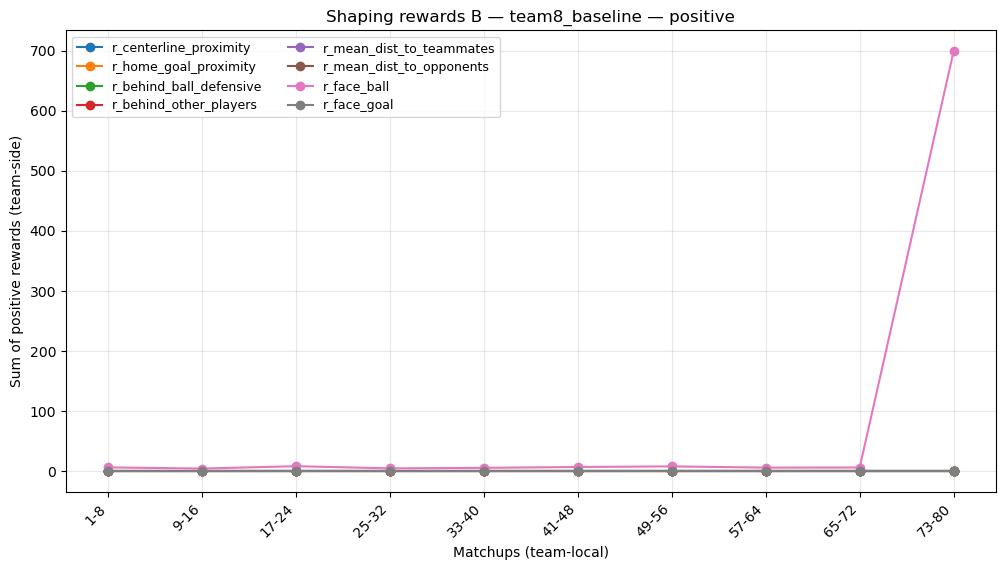

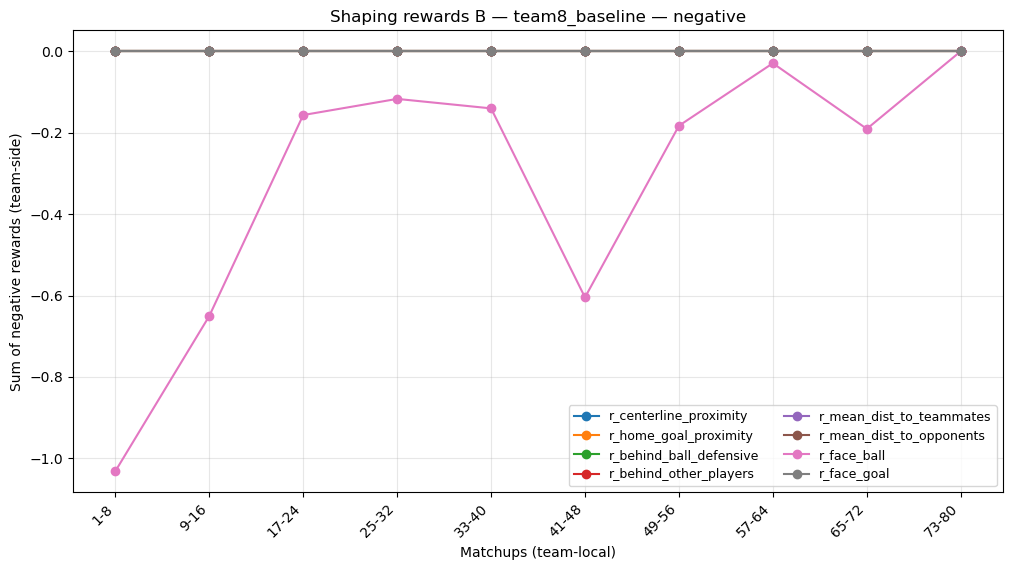

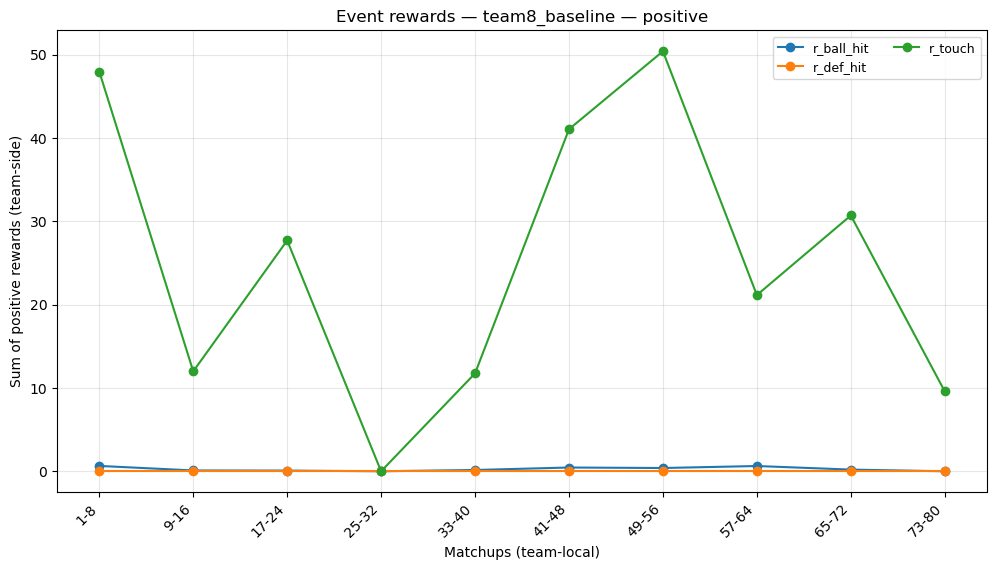

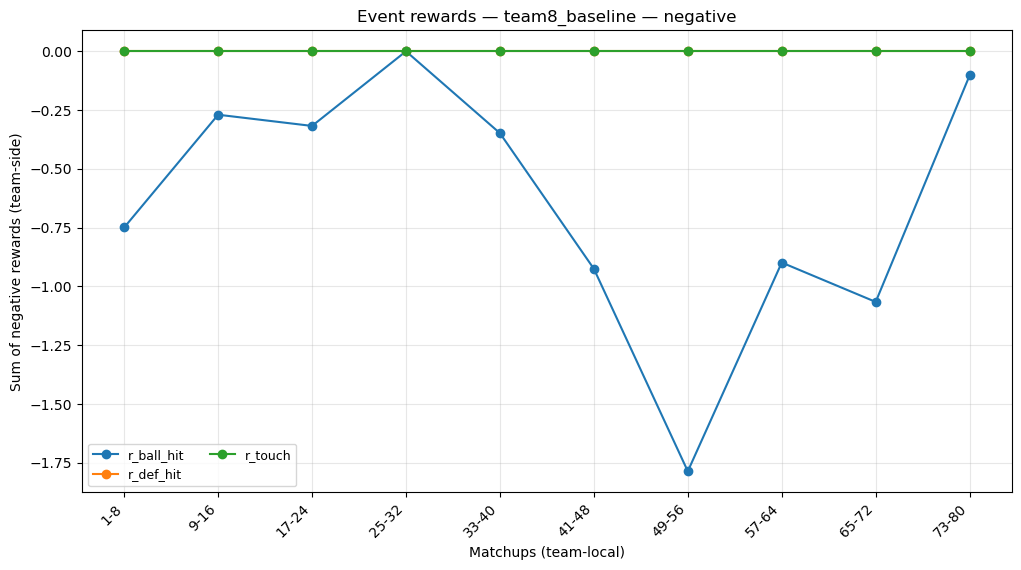

In [32]:
def plot_team_posneg(team: str, reward_cols: list[str], title_prefix: str):
    pos_df, neg_df, cnt_df = aggregate_team_rewards(team, "bucket_round_half", reward_cols)
    x = pos_df["bucket_round_half"].values

    # Pretty x-axis labels as matchup ranges (8 matchups per bucket)
    step = MATCHUPS_PER_BUCKET
    x_labels = [f"{int(b)*step+1}-{(int(b)+1)*step}" for b in x]

    # Positive
    plt.figure(figsize=(12, 6))
    for r in reward_cols:
        plt.plot(x, pos_df[r].values, marker="o", label=r)
    plt.xlabel("Matchups (team-local)")
    plt.ylabel("Sum of positive rewards (team-side)")
    plt.title(f"{title_prefix} — {team} — positive")
    plt.grid(True, alpha=0.3)
    plt.xticks(x, x_labels, rotation=45, ha='right')
    plt.legend(ncols=2, fontsize=9)
    plt.show()

    # Negative
    plt.figure(figsize=(12, 6))
    for r in reward_cols:
        plt.plot(x, neg_df[r].values, marker="o", label=r)
    plt.xlabel("Matchups (team-local)")
    plt.ylabel("Sum of negative rewards (team-side)")
    plt.title(f"{title_prefix} — {team} — negative")
    plt.grid(True, alpha=0.3)
    plt.xticks(x, x_labels, rotation=45, ha='right')
    plt.legend(ncols=2, fontsize=9)
    plt.show()

# Use this list to select teams you want to plot (default: all).
teams_to_plot = teams  # or e.g. teams[:2]

for t in teams_to_plot:
    plot_team_posneg(t, reward_cols_small_a, "Shaping rewards A")
    plot_team_posneg(t, reward_cols_small_b, "Shaping rewards B")
    plot_team_posneg(t, reward_cols_event, "Event rewards")


## 3) Per-team outcomes & behavior metrics + player contribution magnitudes

For each team and `bucket_round_half`, we compute:
- **Goals for** and **goals against** (sum)
- **Average switches** from `low_level_log` (`blue_switches`/`orange_switches`) averaged over the number of team-games in the bucket

Then we plot:
1) Goals for/against
2) Avg switches
3) **Player contribution magnitude** per bucket using the `contrib_*` columns from `low_level_log` as `mean(|contrib_team|)` per bucket.


In [28]:
# Build the same team-local buckets on low_df (do NOT use global round/half indices)
low_team_bucket_map = compute_team_bucket_map(low_df)

contrib_cols = [c for c in low_df.columns if c.startswith("contrib_")]
print("contrib cols:", contrib_cols)

parsed_contrib = {c: parse_pair_series(low_df[c]).values for c in contrib_cols}


contrib cols: ['contrib_s0', 'contrib_s1', 'contrib_s2', 'contrib_s3', 'contrib_s4', 'contrib_s5', 'contrib_p1', 'contrib_p2', 'contrib_p3', 'contrib_d1', 'contrib_d2', 'contrib_d3', 'contrib_d4']


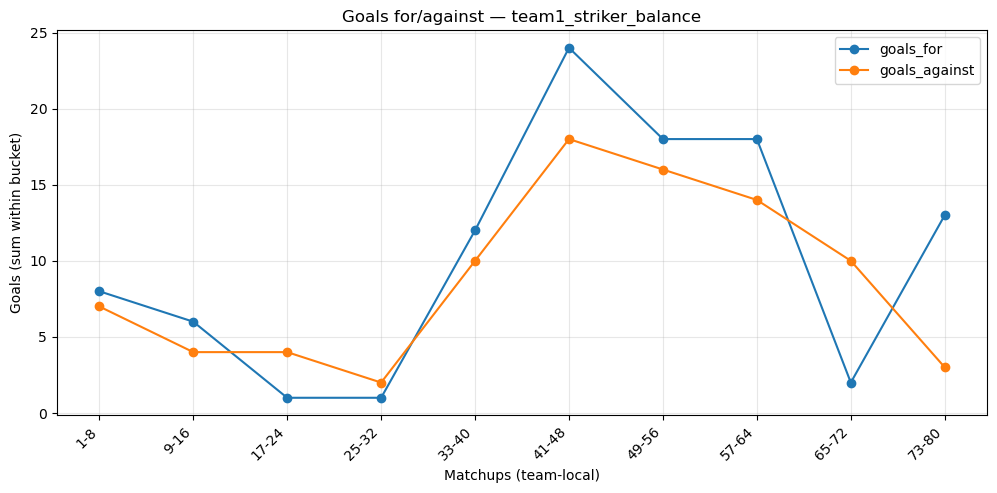

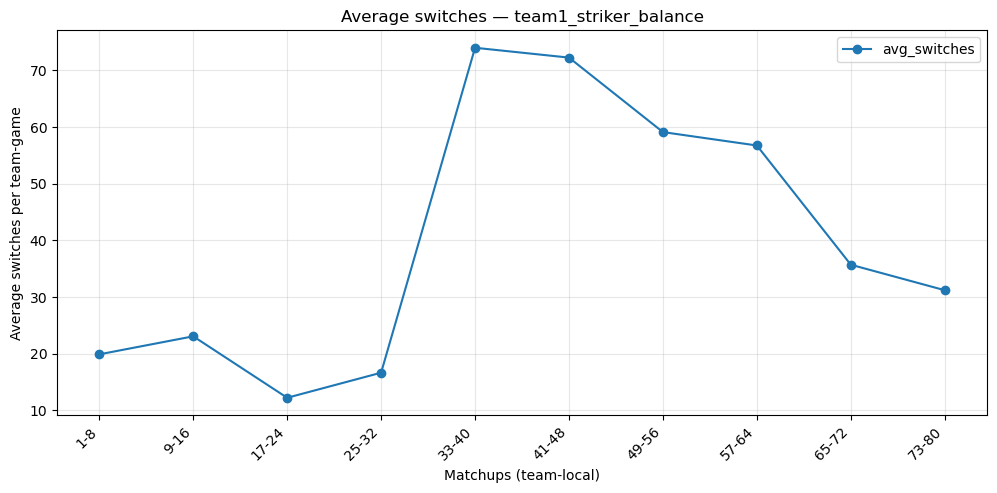

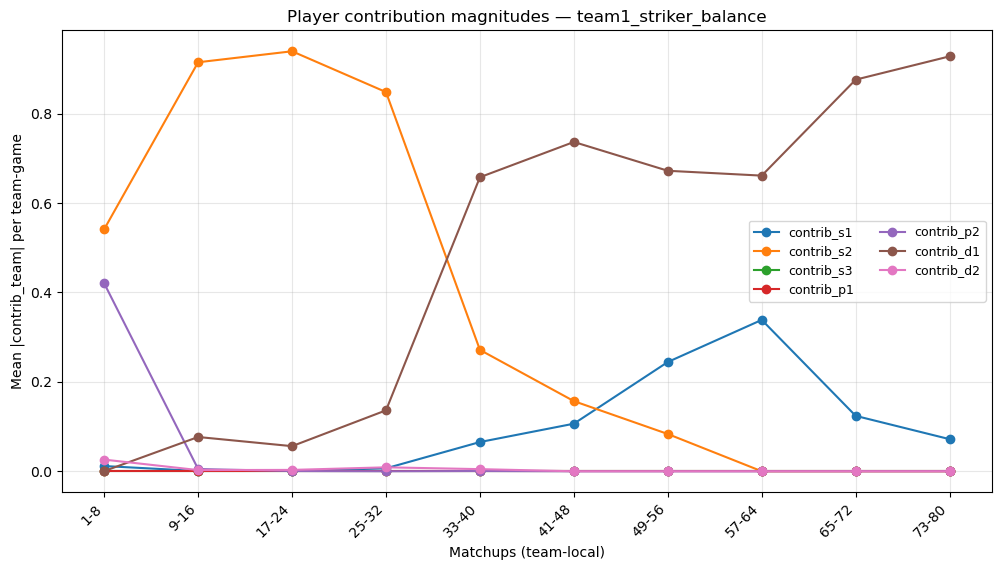

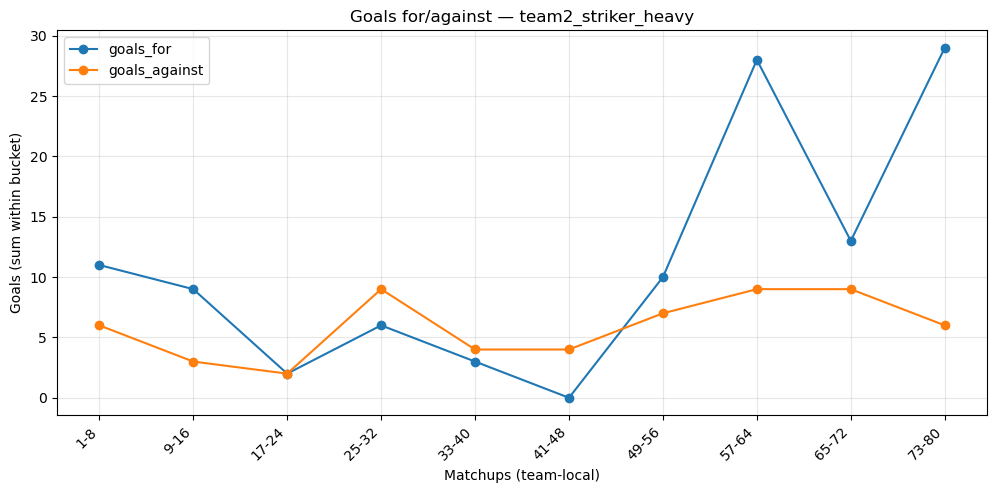

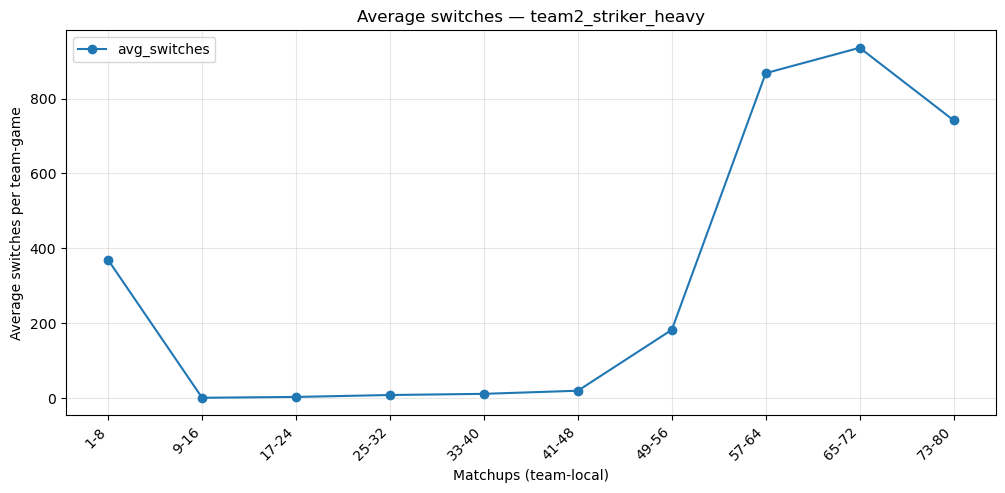

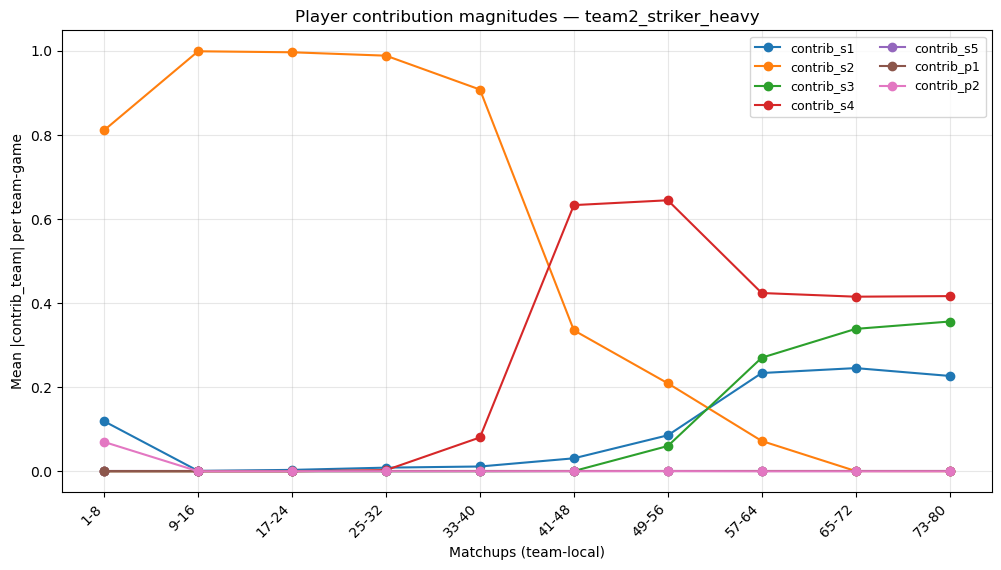

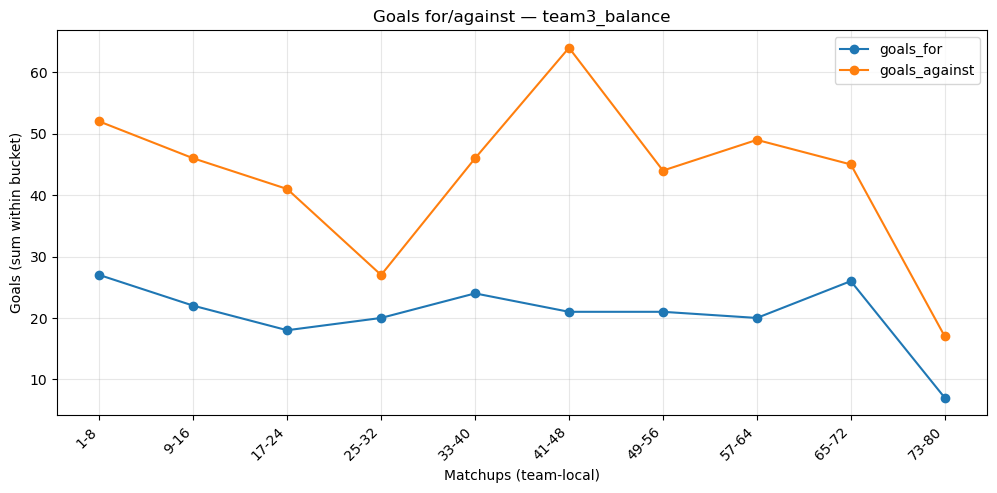

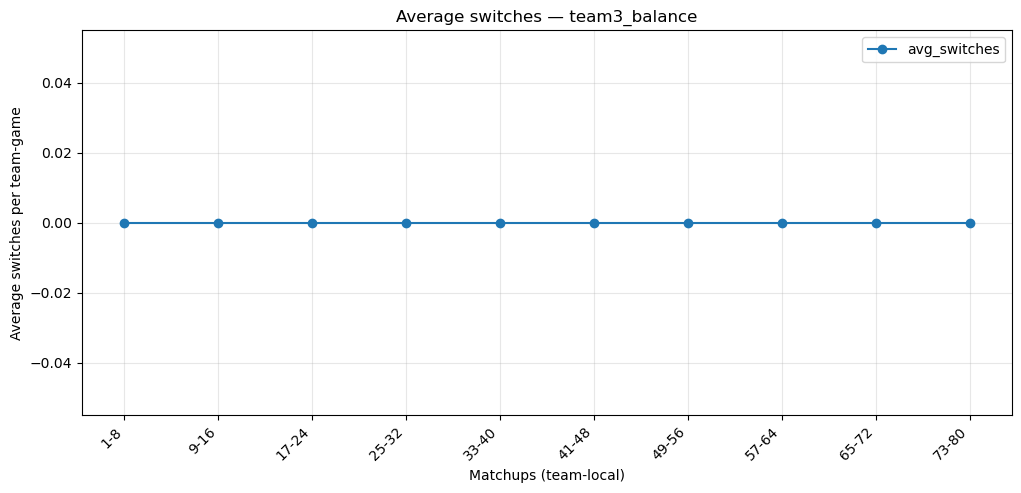

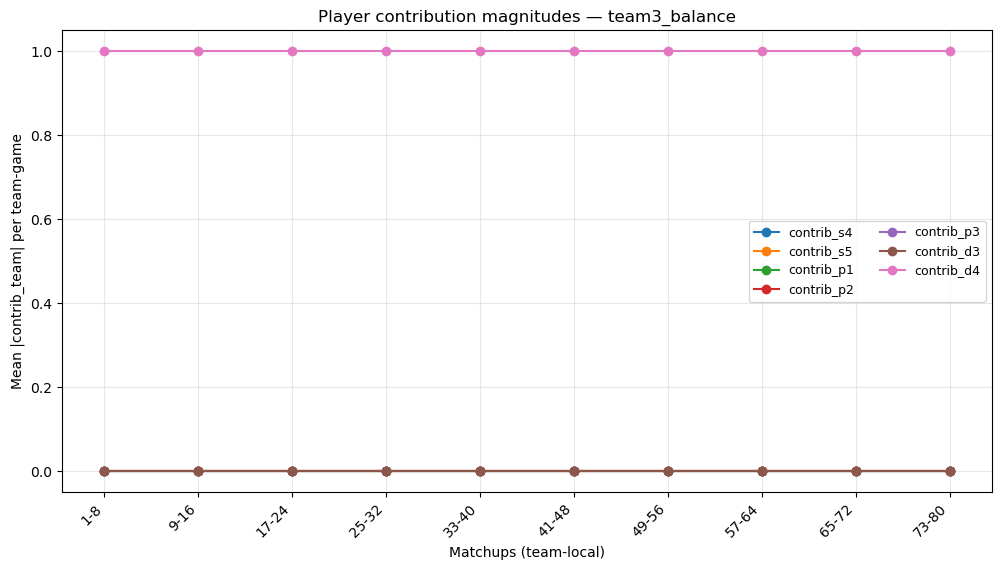

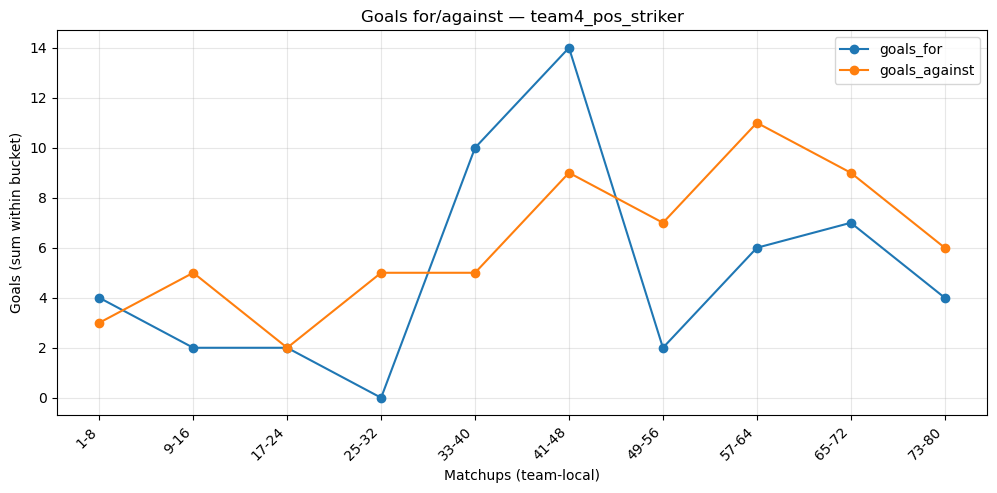

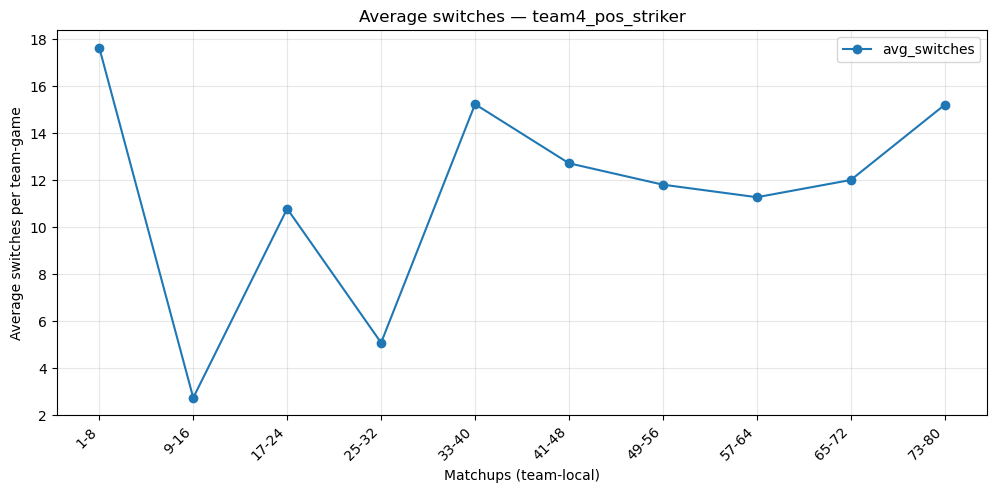

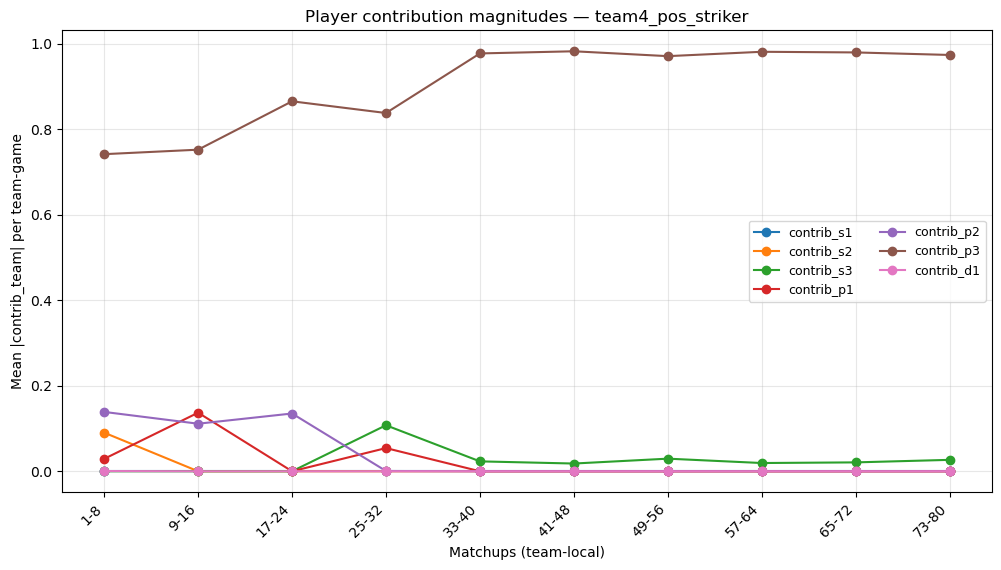

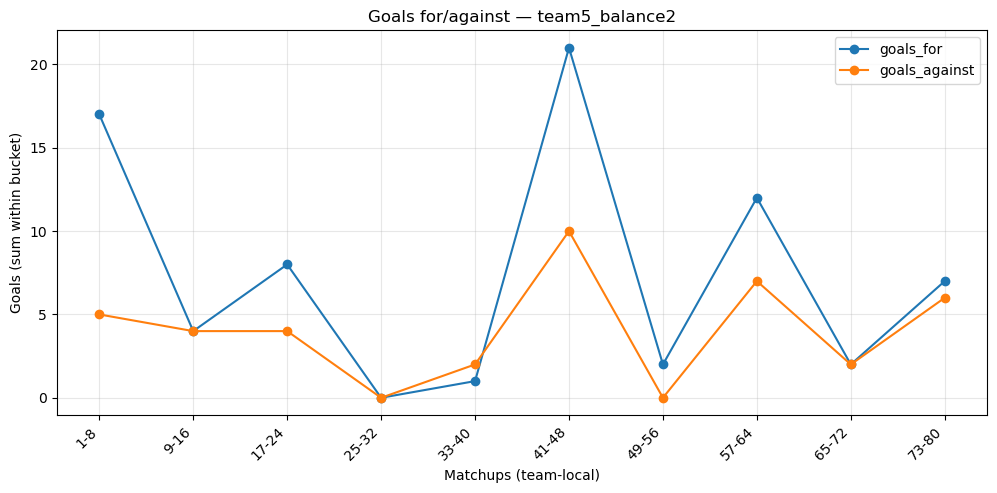

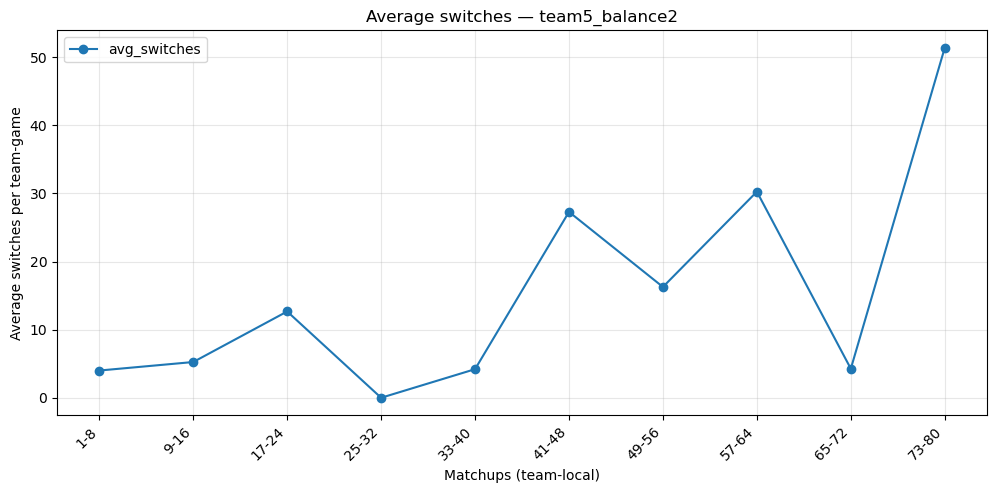

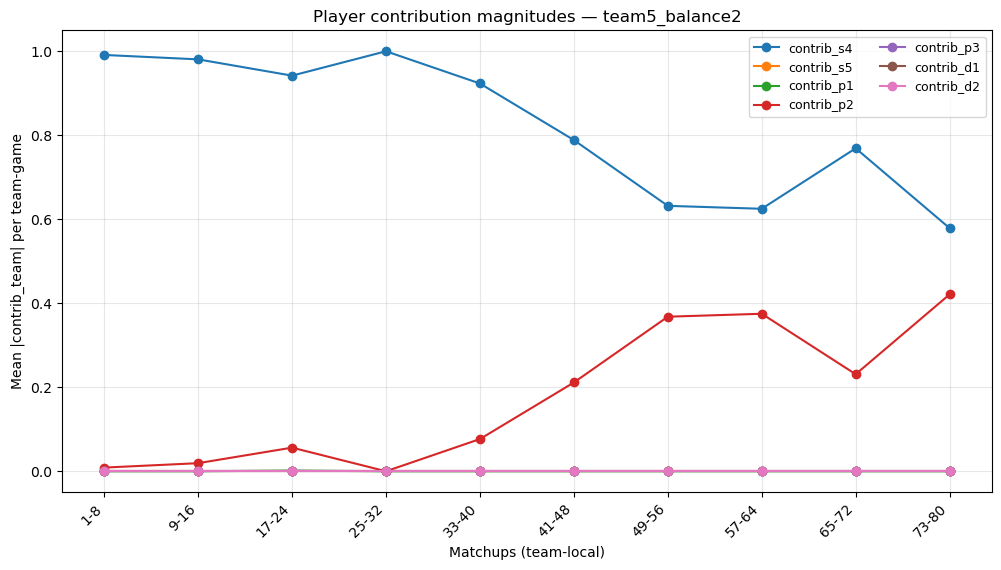

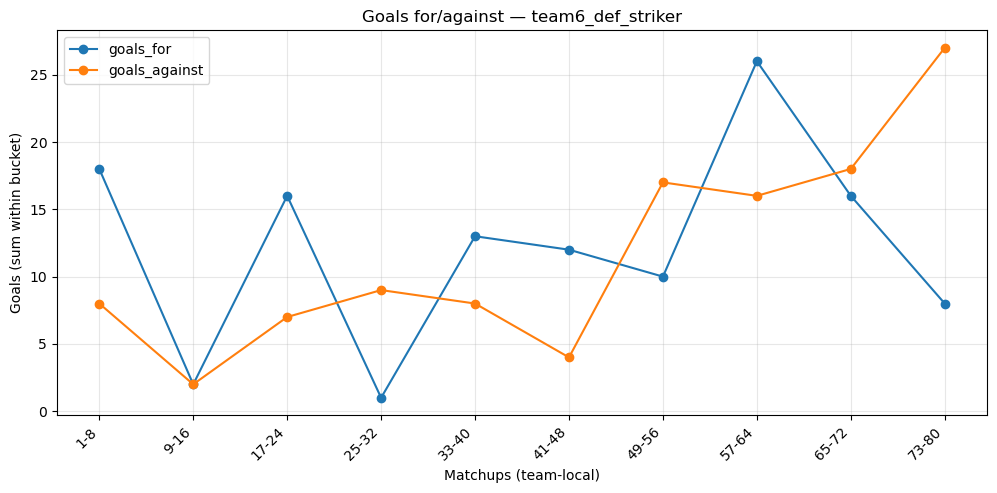

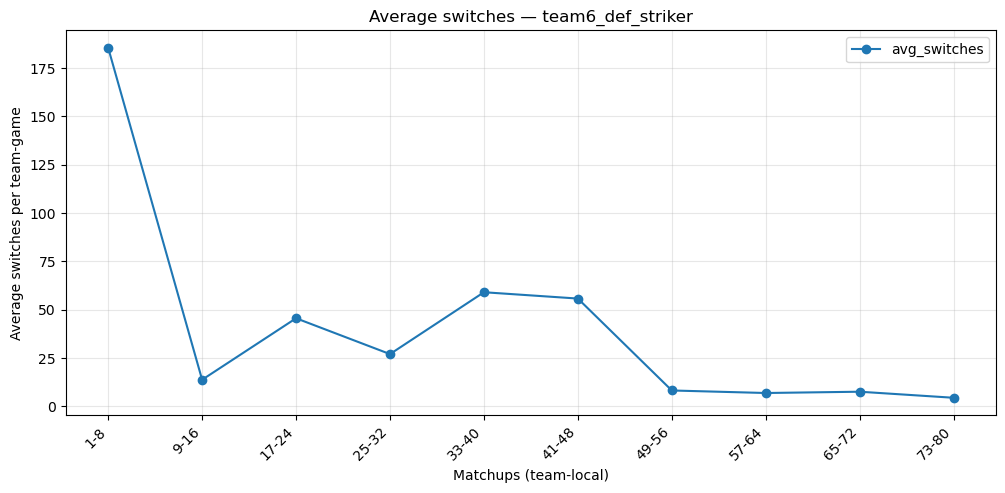

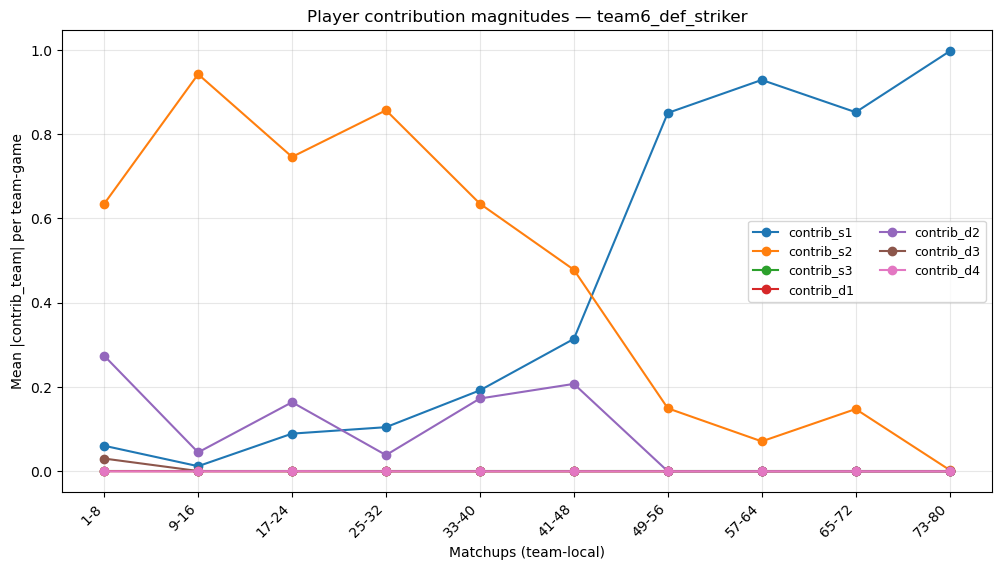

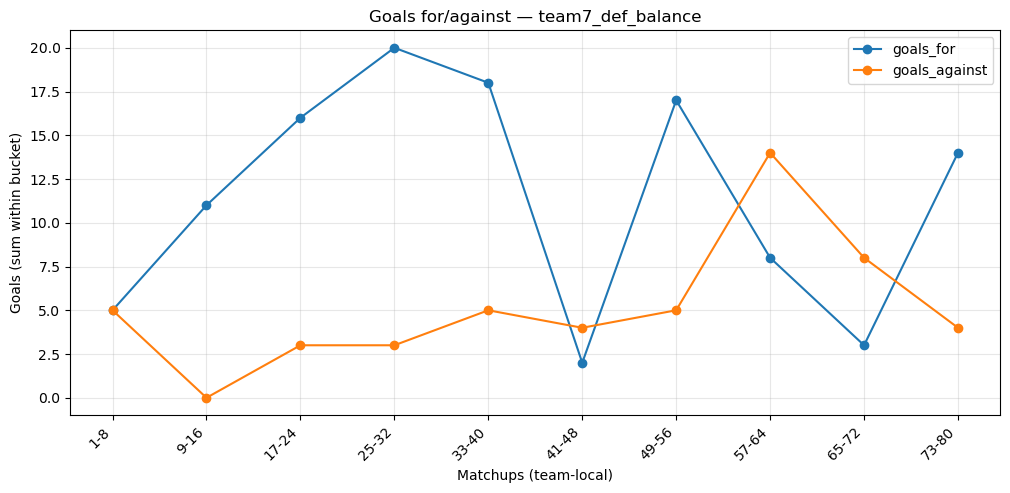

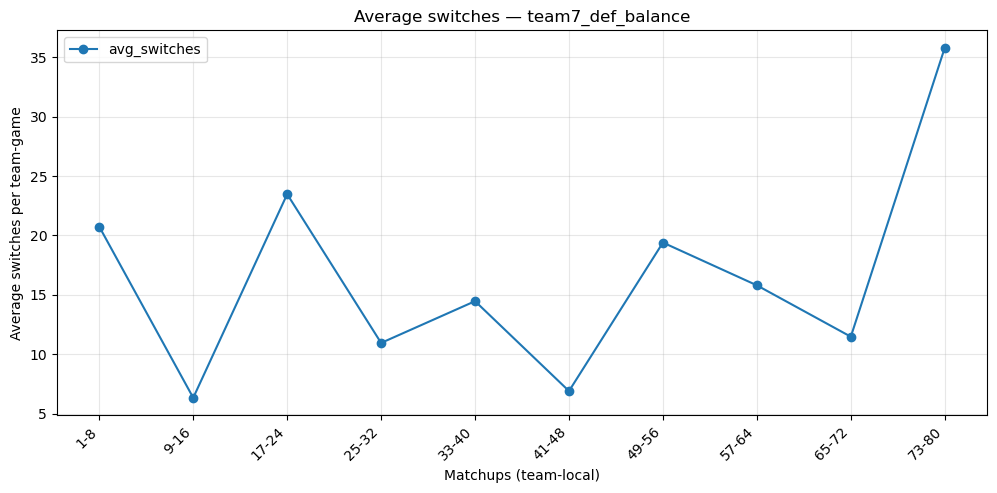

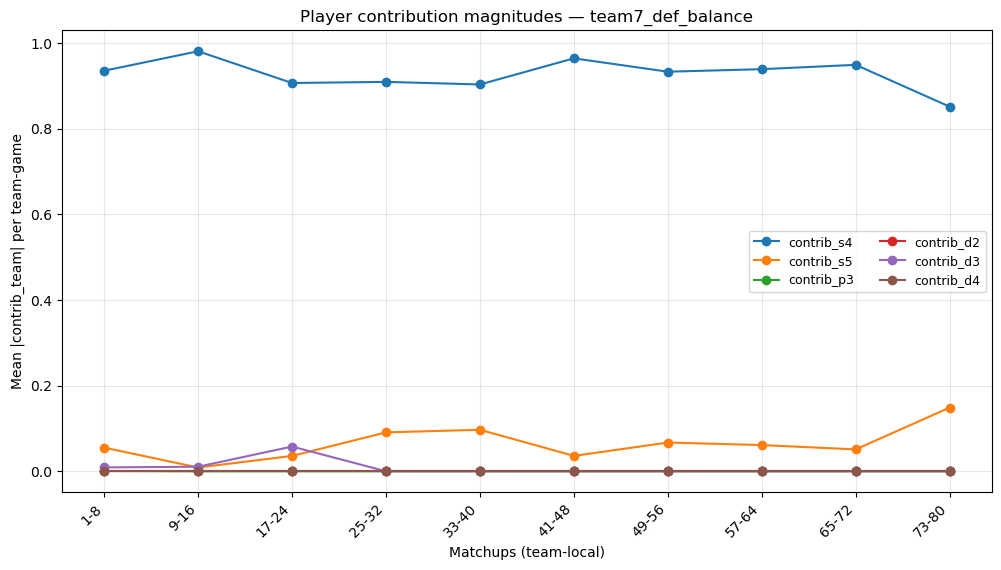

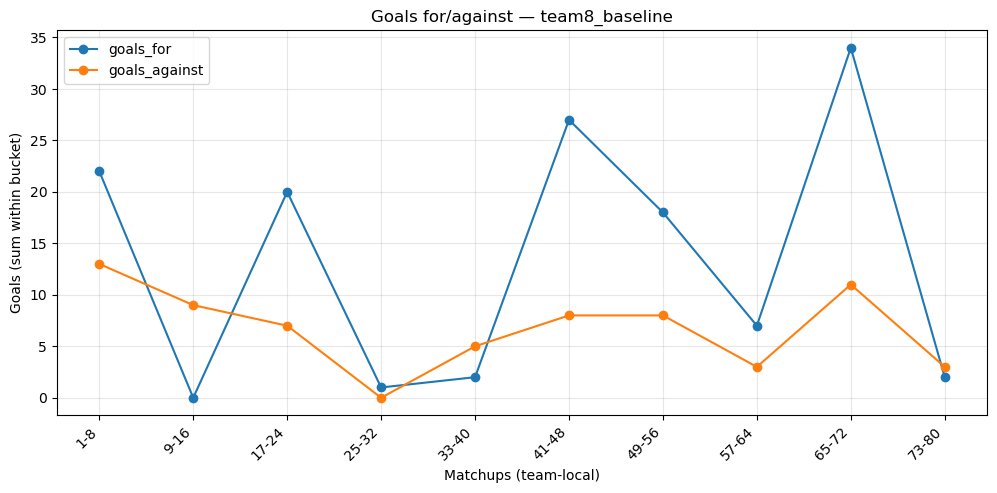

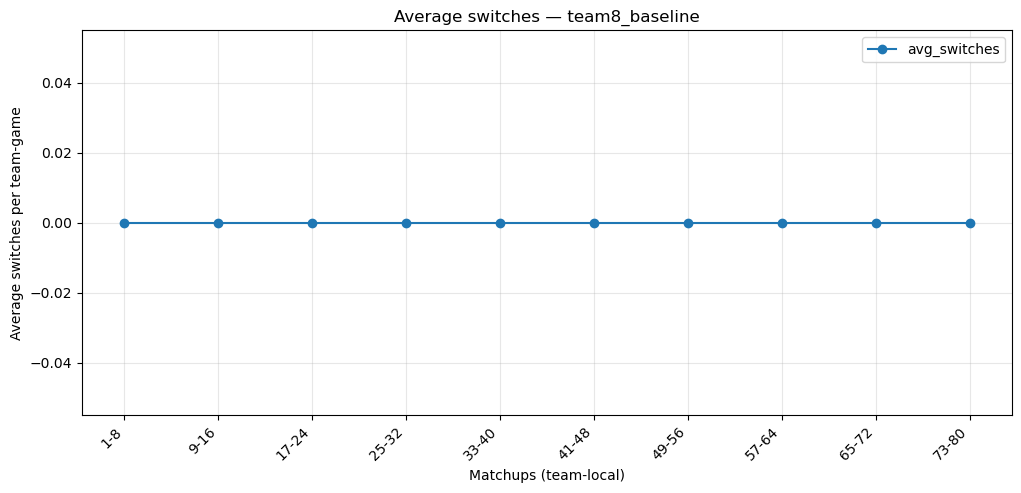

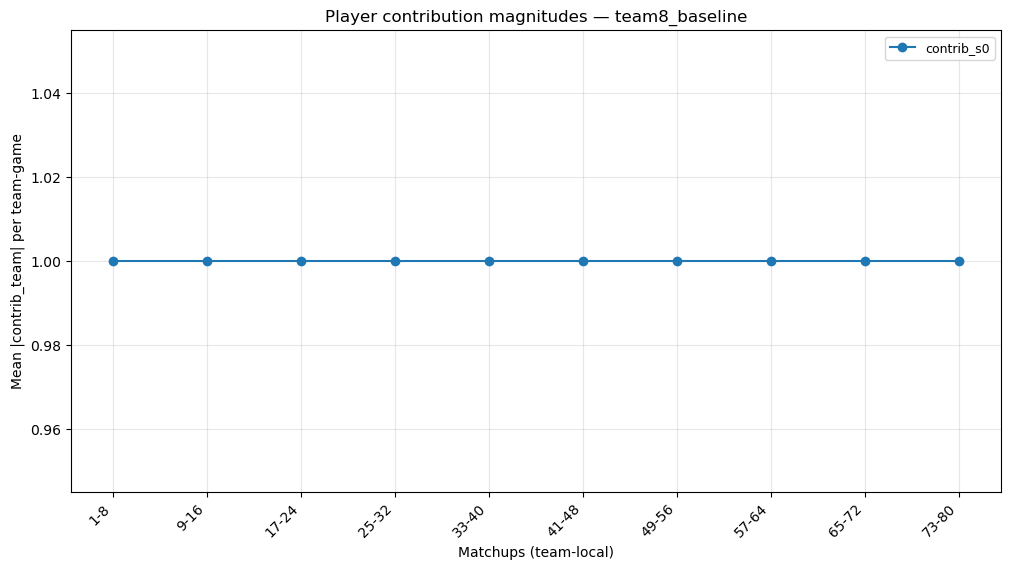

In [29]:
TEAM_SPECS = {
    "team1_striker_balance": ["s1","s2","s3","p1","p2","d1","d2"],
    "team2_striker_heavy":   ["s1","s2","s3","s4","s5","p1","p2"],
    "team3_balance":         ["s4","s5","p1","p2","p3","d3","d4"],
    "team4_pos_striker":     ["s1","s2","s3","p1","p2","p3","d1"],
    "team5_balance2":        ["s4","s5","p1","p2","p3","d1","d2"],
    "team6_def_striker":     ["s1","s2","s3","d1","d2","d3","d4"],
    "team7_def_balance":     ["s4","s5","p3","d2","d3","d4"],
    "team8_baseline":        ["s0"],
}

def aggregate_team_outcomes(team: str) -> pd.DataFrame:
    tb = low_team_bucket_map.get(team)
    if tb is None or len(tb) == 0:
        return pd.DataFrame(columns=["bucket_round_half","goals_for","goals_against","avg_switches","team_games"])

    buckets = sorted(tb.unique())
    out = pd.DataFrame({
        "bucket_round_half": buckets,
        "goals_for": np.zeros(len(buckets)),
        "goals_against": np.zeros(len(buckets)),
        "avg_switches": np.zeros(len(buckets)),
        "team_games": np.zeros(len(buckets), dtype=int),
    })
    idx = {b:i for i,b in enumerate(buckets)}
    switches_sum = np.zeros(len(buckets))

    for j, row in low_df.iterrows():
        if j not in tb.index:
            continue
        b = int(tb.loc[j])
        i = idx[b]
        blue_t = row["blue_team"]
        orange_t = row["orange_team"]

        # blue side
        if team == blue_t:
            out.loc[i, "goals_for"] += row["blue_score"]
            out.loc[i, "goals_against"] += row["orange_score"]
            switches_sum[i] += row.get("blue_switches", 0)
            out.loc[i, "team_games"] += 1

        # orange side
        if team == orange_t:
            out.loc[i, "goals_for"] += row["orange_score"]
            out.loc[i, "goals_against"] += row["blue_score"]
            switches_sum[i] += row.get("orange_switches", 0)
            out.loc[i, "team_games"] += 1

    denom = out["team_games"].to_numpy(dtype=float)
    out["avg_switches"] = np.divide(
        switches_sum,
        denom,
        out=np.full_like(denom, np.nan, dtype=float),
        where=denom > 0,
    )
    return out

def aggregate_team_contrib_magnitude(team: str, contrib_cols_use: list[str]) -> pd.DataFrame:
    tb = low_team_bucket_map.get(team)
    if tb is None or len(tb) == 0:
        return pd.DataFrame(columns=["bucket_round_half","team_games"] + contrib_cols_use)

    buckets = sorted(tb.unique())
    out = pd.DataFrame({"bucket_round_half": buckets})
    counts = pd.Series(0, index=buckets, dtype=int)

    acc = {c: pd.Series(0.0, index=buckets) for c in contrib_cols_use}

    for i, row in low_df.iterrows():
        if i not in tb.index:
            continue
        b = int(tb.loc[i])
        blue_t = row["blue_team"]
        orange_t = row["orange_team"]

        appeared = 0
        if team == blue_t: appeared += 1
        if team == orange_t: appeared += 1
        if appeared == 0:
            continue

        counts[b] += appeared
        for c in contrib_cols_use:
            pair = parsed_contrib[c][i]  # [blue, orange]
            vals = team_side_values_for_match(team, blue_t, orange_t, pair)
            for v in vals:
                acc[c].loc[b] += abs(v)

    denom = counts.to_numpy(dtype=float)
    for c in contrib_cols_use:
        num = acc[c].to_numpy(dtype=float)
        out[c] = np.divide(num, denom, out=np.full_like(denom, np.nan, dtype=float), where=denom > 0)

    out["team_games"] = counts.values
    return out

def plot_team_outcomes_and_contrib(team: str):
    outcomes = aggregate_team_outcomes(team)
    x = outcomes["bucket_round_half"].values
    step = MATCHUPS_PER_BUCKET
    x_labels = [f"{int(b)*step+1}-{(int(b)+1)*step}" for b in x]

    # Graph A: goals
    plt.figure(figsize=(12, 5))
    plt.plot(x, outcomes["goals_for"].values, marker="o", label="goals_for")
    plt.plot(x, outcomes["goals_against"].values, marker="o", label="goals_against")
    plt.xlabel("Matchups (team-local)")
    plt.ylabel("Goals (sum within bucket)")
    plt.title(f"Goals for/against — {team}")
    plt.grid(True, alpha=0.3)
    plt.xticks(x, x_labels, rotation=45, ha='right')
    plt.legend()
    plt.show()

    # Graph B: avg switches
    plt.figure(figsize=(12, 5))
    plt.plot(x, outcomes["avg_switches"].values, marker="o", label="avg_switches")
    plt.xlabel("Matchups (team-local)")
    plt.ylabel("Average switches per team-game")
    plt.title(f"Average switches — {team}")
    plt.grid(True, alpha=0.3)
    plt.xticks(x, x_labels, rotation=45, ha='right')
    plt.legend()
    plt.show()

    # Graph C: player contribution magnitudes (ONLY players on this team)
    players = TEAM_SPECS.get(team, [])
    contrib_cols_use = [f"contrib_{p}" for p in players if f"contrib_{p}" in parsed_contrib]

    if len(contrib_cols_use) == 0:
        print(f"[{team}] No contrib_* columns matched TEAM_SPECS; skipping contrib plot.")
        return

    contrib = aggregate_team_contrib_magnitude(team, contrib_cols_use)
    x2 = contrib["bucket_round_half"].values
    step2 = MATCHUPS_PER_BUCKET
    x_labels2 = [f"{int(b)*step2+1}-{(int(b)+1)*step2}" for b in x2]

    plt.figure(figsize=(12, 6))
    for c in contrib_cols_use:
        plt.plot(x2, contrib[c].values, marker="o", label=c)
    plt.xlabel("Matchups (team-local)")
    plt.ylabel("Mean |contrib_team| per team-game")
    plt.title(f"Player contribution magnitudes — {team}")
    plt.grid(True, alpha=0.3)
    plt.xticks(x2, x_labels2, rotation=45, ha='right')
    plt.legend(ncols=2, fontsize=9)
    plt.show()

for t in teams_to_plot:
    plot_team_outcomes_and_contrib(t)
